# Social vs Nonsocial Syllable Transition DA Analysis

This notebook mirrors the transition-to-DA alignment workflow from
syllable_transition_da_alignment.ipynb, but adds context-aware comparisons:

- Compare DA dynamics for the most common 
onsocial vs social transitions
- Within social transitions, compare gent_in_subject vs subject_in_agent
- Optionally keep oth as a third social-role category when it appears

The workflow assumes the subject-track syllable labels and the home-cage DA table
are aligned closely enough to merge by nearest timestamp.


In [1]:
print("hello")

hello


In [12]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_context("talk")
sns.set_style("whitegrid")


def find_repo_root():
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "Pose_Tracking").exists() and (candidate / "Keypoint_moseq_analysis").exists():
            return candidate
    return cwd


ROOT = find_repo_root()
POSE_DIR = ROOT / "Pose_Tracking"

DA_PATH = r"C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\home_cage_pose_DA_all.csv"

SYLLABLE_PATH = r"C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Keypoint_moseq_analysis\keypoint_moseq_project_home_cage\2026_05_13-23_29_52\syllable_frames_merged.csv"

TRACK_NAME = "subject"
BOUT_PHASES = ["Short_Term-1", "Short_Term-2", "Long_Term-1", "Novel-1"]
PRE_S = 3.0
POST_S = 3.0
TOP_N_TRANSITIONS = 8
MIN_EVENTS_PER_TRANSITION = 8
SHORT_TERM_1_MAX_S = 300

PREFIX_TO_REGION = {"n": "NAc", "p": "mPFC"}
REGION_ORDER = ["NAc", "mPFC"]
REGION_COLORS = {"NAc": "#15616F", "mPFC": "#FFAF00"}

CONTEXT_COLORS = {
    "nonsocial": "#6C757D",
    "social": "#2A9D8F",
    "agent_in_subject": "#15616F",
    "subject_in_agent": "#C44536",
    "both": "#F4A259",
    "none": "#6C757D",
}

if str(POSE_DIR) not in sys.path:
    sys.path.insert(0, str(POSE_DIR))



In [13]:
def infer_region_from_subject(subject_name):
    subject_name = str(subject_name).strip().lower()
    return PREFIX_TO_REGION.get(subject_name[:1], pd.NA)


da_cols = [
    "time_s",
    "brain_region",
    "mouse_identity",
    "zscore_DA",
    "intruder_identity",
    "behavior_active",
    "agent_in_subject",
    "subject_in_agent",
]

syllable_cols = [
    "recording_name",
    "frame_index",
    "syllable",
    "time_s",
    "subject_name",
    "track_name",
    "fps",
]

da_df = pd.read_csv(DA_PATH, usecols=da_cols)
da_df["time_s"] = pd.to_numeric(da_df["time_s"], errors="coerce")
da_df["zscore_DA"] = pd.to_numeric(da_df["zscore_DA"], errors="coerce")
da_df = da_df.dropna(subset=["time_s", "zscore_DA"]).copy()
da_df = da_df[da_df["intruder_identity"].isin(BOUT_PHASES)].copy()
da_df["mouse_identity"] = da_df["mouse_identity"].astype(str)
da_df["brain_region_inferred"] = da_df["mouse_identity"].map(infer_region_from_subject)
da_df = da_df.sort_values(["mouse_identity", "brain_region", "intruder_identity", "time_s"]).reset_index(drop=True)

syll_df = pd.read_csv(SYLLABLE_PATH, usecols=syllable_cols)
syll_df = syll_df[syll_df["track_name"].eq(TRACK_NAME)].copy()
syll_df["time_s"] = pd.to_numeric(syll_df["time_s"], errors="coerce")
syll_df["syllable"] = pd.to_numeric(syll_df["syllable"], errors="coerce").astype("Int64")
syll_df["fps"] = pd.to_numeric(syll_df["fps"], errors="coerce")
syll_df = syll_df.dropna(subset=["time_s", "syllable"]).copy()
syll_df["subject_name"] = syll_df["subject_name"].astype(str)
syll_df["brain_region"] = syll_df["subject_name"].map(infer_region_from_subject)
syll_df = syll_df.sort_values(["recording_name", "frame_index"]).reset_index(drop=True)

display(
    da_df[["mouse_identity", "brain_region", "brain_region_inferred"]]
    .drop_duplicates()
    .sort_values(["brain_region", "mouse_identity"])
    .reset_index(drop=True)
)

display(syll_df.head())


,mouse_identity,brain_region,brain_region_inferred
0,n5,NAc,NAc
1,n6,NAc,NAc
2,n7,NAc,NAc
3,nn1,NAc,NAc
4,nn2,NAc,NAc
5,nn3,NAc,NAc
6,nn4,NAc,NAc
7,nn5,NAc,NAc
8,nn6,NAc,NAc
9,nn7,NAc,NAc


,recording_name,frame_index,syllable,time_s,subject_name,track_name,fps,brain_region
0,n5_subject,0,1,0.0,n5,subject,10.0,NAc
1,n5_subject,1,1,0.1,n5,subject,10.0,NAc
2,n5_subject,2,1,0.2,n5,subject,10.0,NAc
3,n5_subject,3,1,0.3,n5,subject,10.0,NAc
4,n5_subject,4,1,0.4,n5,subject,10.0,NAc


In [14]:
def build_bout_windows(da_frame, short_term_1_max_s=None):
    bout_windows = (
        da_frame.groupby(["mouse_identity", "brain_region", "intruder_identity"], as_index=False)
        .agg(
            bout_start_s=("time_s", "min"),
            bout_end_s=("time_s", "max"),
            n_da_samples=("time_s", "size"),
        )
        .rename(columns={"intruder_identity": "bout_phase"})
        .sort_values(["brain_region", "mouse_identity", "bout_phase"])
        .reset_index(drop=True)
    )

    if short_term_1_max_s is not None:
        st1_mask = bout_windows["bout_phase"].eq("Short_Term-1")
        clipped_end = bout_windows.loc[st1_mask, "bout_start_s"] + float(short_term_1_max_s)
        bout_windows.loc[st1_mask, "bout_end_s"] = np.minimum(
            bout_windows.loc[st1_mask, "bout_end_s"].to_numpy(dtype=float),
            clipped_end.to_numpy(dtype=float),
        )

    return bout_windows


def label_syllables_with_bouts(syllable_frame, bout_windows):
    parts = []
    for (subject_name, brain_region), rec in syllable_frame.groupby(["subject_name", "brain_region"], sort=False):
        rec = rec.copy().sort_values(["recording_name", "frame_index"]).reset_index(drop=True)
        rec["bout_phase"] = pd.NA
        rec["bout_start_s"] = np.nan
        rec["bout_end_s"] = np.nan

        subject_windows = bout_windows[
            (bout_windows["mouse_identity"] == subject_name)
            & (bout_windows["brain_region"] == brain_region)
        ]
        for _, win in subject_windows.iterrows():
            mask = rec["time_s"].between(win["bout_start_s"], win["bout_end_s"], inclusive="both")
            rec.loc[mask, "bout_phase"] = win["bout_phase"]
            rec.loc[mask, "bout_start_s"] = win["bout_start_s"]
            rec.loc[mask, "bout_end_s"] = win["bout_end_s"]
        parts.append(rec)

    return pd.concat(parts, ignore_index=True)


def classify_social_role(agent_in_subject, subject_in_agent):
    agent_yes = pd.Series(agent_in_subject).eq("Yes").to_numpy()
    subject_yes = pd.Series(subject_in_agent).eq("Yes").to_numpy()
    return np.select(
        [agent_yes & subject_yes, agent_yes, subject_yes],
        ["both", "agent_in_subject", "subject_in_agent"],
        default="none",
    )


def add_social_context_to_syllables(syllable_frame, da_frame):
    parts = []
    da_join_cols = [
        "time_s",
        "behavior_active",
        "agent_in_subject",
        "subject_in_agent",
    ]
    for (subject_name, brain_region, bout_phase), rec in syllable_frame.groupby(
        ["subject_name", "brain_region", "bout_phase"], dropna=False, sort=False
    ):
        rec = rec.copy().sort_values("time_s").reset_index(drop=True)
        if pd.isna(bout_phase):
            rec["behavior_active"] = pd.NA
            rec["agent_in_subject"] = pd.NA
            rec["subject_in_agent"] = pd.NA
            rec["social_proximity"] = False
            rec["social_role"] = "none"
            parts.append(rec)
            continue

        da_rec = da_frame[
            (da_frame["mouse_identity"] == subject_name)
            & (da_frame["brain_region"] == brain_region)
            & (da_frame["intruder_identity"] == bout_phase)
        ][da_join_cols].sort_values("time_s").reset_index(drop=True)

        if da_rec.empty:
            rec["behavior_active"] = pd.NA
            rec["agent_in_subject"] = pd.NA
            rec["subject_in_agent"] = pd.NA
            rec["social_proximity"] = False
            rec["social_role"] = "none"
            parts.append(rec)
            continue

        merged = pd.merge_asof(
            rec,
            da_rec,
            on="time_s",
            direction="nearest",
            tolerance=0.11,
        )
        merged["social_proximity"] = (
            merged["agent_in_subject"].eq("Yes")
            | merged["subject_in_agent"].eq("Yes")
        )
        merged["social_role"] = classify_social_role(
            merged["agent_in_subject"],
            merged["subject_in_agent"],
        )
        parts.append(merged)

    return pd.concat(parts, ignore_index=True)


def extract_syllable_runs(frame, syllable_col="syllable"):
    rows = []
    for recording_name, rec in frame.groupby("recording_name", sort=False):
        rec = rec.sort_values("frame_index").reset_index(drop=True)
        if rec.empty:
            continue
        run_id = rec[syllable_col].ne(rec[syllable_col].shift()).cumsum()
        part = rec.groupby(run_id, sort=False).agg(
            subject_name=("subject_name", "first"),
            brain_region=("brain_region", "first"),
            bout_phase=("bout_phase", "first"),
            syllable=(syllable_col, "first"),
            start_time_s=("time_s", "first"),
            end_time_s=("time_s", "last"),
            n_frames=("frame_index", "size"),
            fps=("fps", "first"),
        ).reset_index(drop=True)
        part.insert(0, "recording_name", recording_name)
        part["duration_s"] = (part["end_time_s"] - part["start_time_s"]) + (1.0 / part["fps"].fillna(10.0))
        rows.append(part)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


def extract_syllable_transitions(frame, syllable_col="syllable"):
    rows = []
    for recording_name, rec in frame.groupby("recording_name", sort=False):
        rec = rec.sort_values("frame_index").reset_index(drop=True)
        if len(rec) < 2:
            continue
        prev = rec.iloc[:-1].reset_index(drop=True)
        curr = rec.iloc[1:].reset_index(drop=True)
        consecutive = (curr["frame_index"].to_numpy() - prev["frame_index"].to_numpy()) == 1
        if not consecutive.any():
            continue
        part = pd.DataFrame(
            {
                "recording_name": recording_name,
                "subject_name": curr.loc[consecutive, "subject_name"].to_numpy(),
                "brain_region": curr.loc[consecutive, "brain_region"].to_numpy(),
                "entry_time_s": curr.loc[consecutive, "time_s"].to_numpy(),
                "entry_frame_index": curr.loc[consecutive, "frame_index"].to_numpy(),
                "from_syllable": prev.loc[consecutive, syllable_col].to_numpy(),
                "to_syllable": curr.loc[consecutive, syllable_col].to_numpy(),
                "bout_phase": curr.loc[consecutive, "bout_phase"].to_numpy(),
                "bout_start_s": curr.loc[consecutive, "bout_start_s"].to_numpy(),
                "bout_end_s": curr.loc[consecutive, "bout_end_s"].to_numpy(),
                "behavior_active": curr.loc[consecutive, "behavior_active"].to_numpy()
                if "behavior_active" in curr.columns
                else np.repeat(pd.NA, consecutive.sum()),
                "agent_in_subject": curr.loc[consecutive, "agent_in_subject"].to_numpy()
                if "agent_in_subject" in curr.columns
                else np.repeat(pd.NA, consecutive.sum()),
                "subject_in_agent": curr.loc[consecutive, "subject_in_agent"].to_numpy()
                if "subject_in_agent" in curr.columns
                else np.repeat(pd.NA, consecutive.sum()),
                "social_proximity": curr.loc[consecutive, "social_proximity"].to_numpy()
                if "social_proximity" in curr.columns
                else np.repeat(False, consecutive.sum()),
                "social_role": curr.loc[consecutive, "social_role"].to_numpy()
                if "social_role" in curr.columns
                else np.repeat("none", consecutive.sum()),
            }
        )
        part["changed"] = part["from_syllable"] != part["to_syllable"]
        part = part[part["changed"]].copy()
        part["transition_label"] = (
            part["from_syllable"].astype(str) + "->" + part["to_syllable"].astype(str)
        )
        rows.append(part)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out = out.dropna(subset=["bout_phase"]).reset_index(drop=True)
    out.insert(0, "event_id", np.arange(len(out)))
    out["interaction_context"] = np.where(out["social_proximity"], "social", "nonsocial")
    return out


In [15]:
def align_transitions_to_da(transitions_df, da_frame, pre_s=3.0, post_s=3.0):
    aligned_events = []
    aligned_rows = []
    for key, da_rec in da_frame.groupby(["mouse_identity", "brain_region", "intruder_identity"], sort=False):
        da_rec = da_rec.sort_values("time_s").reset_index(drop=True)
        mouse_identity, brain_region, bout_phase = key
        dt = da_rec["time_s"].diff().dropna().median()
        if pd.isna(dt) or dt <= 0:
            dt = 0.1

        rel_grid = np.round(np.arange(-pre_s, post_s + (dt / 2.0), dt), 6)
        group_start = float(da_rec["time_s"].min())
        group_end = float(da_rec["time_s"].max())
        events = transitions_df[
            (transitions_df["subject_name"] == mouse_identity)
            & (transitions_df["brain_region"] == brain_region)
            & (transitions_df["bout_phase"] == bout_phase)
        ]

        for _, event in events.iterrows():
            entry_time = float(event["entry_time_s"])
            if entry_time - pre_s < group_start or entry_time + post_s > group_end:
                continue

            seg = da_rec[
                da_rec["time_s"].between(entry_time - pre_s, entry_time + post_s, inclusive="both")
            ].copy()
            if seg.empty:
                continue

            rel_time = seg["time_s"].to_numpy(dtype=float) - entry_time
            trace = np.interp(rel_grid, rel_time, seg["zscore_DA"].to_numpy(dtype=float))
            center_idx = int(np.abs(rel_time).argmin())
            center_row = seg.iloc[center_idx]

            pre_mask = rel_grid < 0
            post_mask = rel_grid >= 0
            if (not pre_mask.any()) or (not post_mask.any()):
                continue

            event_record = event.to_dict()
            event_record.update(
                {
                    "dt_s": float(dt),
                    "zscore_at_transition": float(center_row["zscore_DA"]),
                    "behavior_active_at_transition": center_row.get("behavior_active", pd.NA),
                    "agent_in_subject_at_transition": center_row.get("agent_in_subject", pd.NA),
                    "subject_in_agent_at_transition": center_row.get("subject_in_agent", pd.NA),
                    "social_role_at_transition": classify_social_role([center_row.get("agent_in_subject", pd.NA)], [center_row.get("subject_in_agent", pd.NA)])[0],
                    "mean_pre": float(np.nanmean(trace[pre_mask])),
                    "mean_post": float(np.nanmean(trace[post_mask])),
                    "peak_pre": float(np.nanmax(trace[pre_mask])),
                    "peak_post": float(np.nanmax(trace[post_mask])),
                    "peak_latency_s": float(rel_grid[post_mask][np.nanargmax(trace[post_mask])]),
                    "auc_pre": float(np.trapz(trace[pre_mask], dx=float(dt))),
                    "auc_post": float(np.trapz(trace[post_mask], dx=float(dt))),
                    "trace": trace,
                    "rel_time_grid": rel_grid,
                }
            )
            aligned_events.append(event_record)

            for rel_t, z_da in zip(rel_grid, trace):
                aligned_rows.append(
                    {
                        "event_id": event_record["event_id"],
                        "subject_name": mouse_identity,
                        "brain_region": brain_region,
                        "bout_phase": bout_phase,
                        "transition_label": event_record["transition_label"],
                        "from_syllable": event_record["from_syllable"],
                        "to_syllable": event_record["to_syllable"],
                        "entry_time_s": entry_time,
                        "interaction_context": event_record["interaction_context"],
                        "social_role_at_transition": event_record["social_role_at_transition"],
                        "rel_time_s": rel_t,
                        "zscore_DA": z_da,
                    }
                )

    return pd.DataFrame(aligned_events), pd.DataFrame(aligned_rows)


def summarize_transition_counts(events_df, context_col, context_order, region=None, bout_phases=None, min_events=1):
    out = events_df.copy()
    if region is not None:
        out = out[out["brain_region"] == region].copy()
    if bout_phases is not None:
        out = out[out["bout_phase"].isin(bout_phases)].copy()
    out = out[out[context_col].isin(context_order)].copy()
    if out.empty:
        return out

    summary = (
        out.groupby([context_col, "transition_label"], as_index=False)
        .agg(
            n_events=("event_id", "nunique"),
            n_subjects=("subject_name", "nunique"),
        )
        .sort_values([context_col, "n_events", "transition_label"], ascending=[True, False, True])
        .reset_index(drop=True)
    )
    return summary[summary["n_events"] >= int(min_events)].reset_index(drop=True)


def get_context_top_labels(
    events_df,
    region,
    context_col,
    context_order,
    top_n=8,
    bout_phases=None,
    min_events=8,
):
    summary = summarize_transition_counts(
        events_df,
        context_col=context_col,
        context_order=context_order,
        region=region,
        bout_phases=bout_phases,
        min_events=min_events,
    )
    if summary.empty:
        return []

    labels = []
    for context_name in context_order:
        part = summary[summary[context_col] == context_name].head(top_n)
        for label in part["transition_label"]:
            if label not in labels:
                labels.append(label)
    return labels


def _compute_trace_stats(sub):
    if sub.empty:
        return pd.DataFrame(columns=["rel_time_s", "mean", "std", "count", "sem"])
    stats = (
        sub.groupby("rel_time_s")["zscore_DA"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .sort_values("rel_time_s")
    )
    stats["sem"] = stats["std"] / np.sqrt(stats["count"].clip(lower=1))
    return stats


def plot_top_transition_counts_by_context(
    events_df,
    region,
    context_col,
    context_order,
    top_n=10,
    bout_phases=None,
    min_events=8,
    title=None,
):
    summary = summarize_transition_counts(
        events_df,
        context_col=context_col,
        context_order=context_order,
        region=region,
        bout_phases=bout_phases,
        min_events=min_events,
    )
    if summary.empty:
        print(f"No transitions available for {region} and {context_col}")
        return summary

    fig, axes = plt.subplots(1, len(context_order), figsize=(7 * len(context_order), 5), sharey=False)
    axes = np.atleast_1d(axes)

    for ax, context_name in zip(axes, context_order):
        part = summary[summary[context_col] == context_name].head(top_n).copy()
        sns.barplot(
            data=part,
            x="n_events",
            y="transition_label",
            color=CONTEXT_COLORS.get(context_name, "0.5"),
            ax=ax,
        )
        ax.set_title(f"{context_name} (top {len(part)})")
        ax.set_xlabel("Event count")
        ax.set_ylabel("Transition")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if part.empty:
            ax.text(0.5, 0.5, "No transitions", transform=ax.transAxes, ha="center", va="center")

    fig.suptitle(title or f"{region}: most common transitions by {context_col}", y=1.02)
    fig.tight_layout()
    return summary


def plot_transition_peth_by_context(
    long_df,
    events_df,
    region,
    context_col,
    context_order,
    top_n=6,
    bout_phases=None,
    min_events=8,
    title=None,
):
    plot_events = events_df.copy()
    plot_long = long_df.copy()
    if bout_phases is not None:
        plot_events = plot_events[plot_events["bout_phase"].isin(bout_phases)].copy()
        plot_long = plot_long[plot_long["bout_phase"].isin(bout_phases)].copy()

    plot_events = plot_events[
        (plot_events["brain_region"] == region)
        & (plot_events[context_col].isin(context_order))
    ].copy()
    plot_long = plot_long[
        (plot_long["brain_region"] == region)
        & (plot_long[context_col].isin(context_order))
    ].copy()

    top_labels = get_context_top_labels(
        plot_events,
        region=region,
        context_col=context_col,
        context_order=context_order,
        top_n=top_n,
        bout_phases=bout_phases,
        min_events=min_events,
    )
    if not top_labels:
        print(f"No aligned transitions for {region} and {context_col}")
        return

    plot_long = plot_long[plot_long["transition_label"].isin(top_labels)].copy()
    fig, axes = plt.subplots(len(top_labels), 1, figsize=(13, 4.5 * len(top_labels)), sharex=True, sharey=True)
    axes = np.atleast_1d(axes)

    for ax, label in zip(axes, top_labels):
        label_df = plot_long[plot_long["transition_label"] == label].copy()
        for context_name in context_order:
            sub = label_df[label_df[context_col] == context_name].copy()
            stats = _compute_trace_stats(sub)
            if stats.empty:
                continue
            n_events = sub["event_id"].nunique()
            color = CONTEXT_COLORS.get(context_name, "0.5")
            ax.plot(
                stats["rel_time_s"],
                stats["mean"],
                lw=3,
                color=color,
                label=f"{context_name} (n={n_events})",
            )
            ax.fill_between(
                stats["rel_time_s"],
                stats["mean"] - stats["sem"],
                stats["mean"] + stats["sem"],
                color=color,
                alpha=0.18,
            )
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(label, fontsize=20)
        ax.set_ylabel("z-scored DA")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(frameon=False, loc="center left", bbox_to_anchor=(1.02, 0.5))

    axes[-1].set_xlabel("Time from transition (s)")
    fig.suptitle(title or f"{region}: DA around top transitions by {context_col}", y=1.01, fontsize=24)
    fig.tight_layout(rect=[0, 0, 0.83, 0.98])


def plot_transition_metrics_by_context(
    events_df,
    region,
    context_col,
    context_order,
    top_n=6,
    bout_phases=None,
    min_events=8,
    title=None,
):
    plot_df = events_df.copy()
    if bout_phases is not None:
        plot_df = plot_df[plot_df["bout_phase"].isin(bout_phases)].copy()

    plot_df = plot_df[
        (plot_df["brain_region"] == region)
        & (plot_df[context_col].isin(context_order))
    ].copy()

    top_labels = get_context_top_labels(
        plot_df,
        region=region,
        context_col=context_col,
        context_order=context_order,
        top_n=top_n,
        bout_phases=bout_phases,
        min_events=min_events,
    )
    if not top_labels:
        print(f"No aligned transitions for {region} and {context_col}")
        return pd.DataFrame()

    metric_df = plot_df[plot_df["transition_label"].isin(top_labels)].melt(
        id_vars=["event_id", "subject_name", "brain_region", "bout_phase", "transition_label", context_col],
        value_vars=["auc_pre", "auc_post", "mean_pre", "mean_post", "peak_pre", "peak_post"],
        var_name="metric_period",
        value_name="value",
    )
    metric_df[["metric", "period"]] = metric_df["metric_period"].str.extract(r"^(auc|mean|peak)_(pre|post)$")
    metric_df["metric"] = metric_df["metric"].map({"auc": "AUC", "mean": "Mean", "peak": "Peak"})
    metric_df["period"] = metric_df["period"].map({"pre": "Before", "post": "After"})
    metric_df = metric_df.dropna(subset=["metric", "period", "value"]).copy()

    metric_order = ["AUC", "Mean", "Peak"]
    period_order = ["Before", "After"]
    fig, axes = plt.subplots(len(metric_order), len(period_order), figsize=(22, 14), sharex=True)

    for row_idx, metric_name in enumerate(metric_order):
        for col_idx, period_name in enumerate(period_order):
            ax = axes[row_idx, col_idx]
            sub = metric_df[
                (metric_df["metric"] == metric_name)
                & (metric_df["period"] == period_name)
            ].copy()
            sns.barplot(
                data=sub,
                x="transition_label",
                y="value",
                hue=context_col,
                order=top_labels,
                hue_order=context_order,
                palette={k: CONTEXT_COLORS.get(k, "0.5") for k in context_order},
                estimator=np.mean,
                errorbar="se",
                ax=ax,
            )
            ax.set_title(f"{metric_name} | {period_name}")
            ax.set_xlabel("")
            ax.tick_params(axis="x", rotation=45)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.set_ylabel(metric_name if col_idx == 0 else "")
            if ax.legend_ is not None:
                if row_idx == 0 and col_idx == len(period_order) - 1:
                    ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", title=context_col)
                else:
                    ax.legend_.remove()

    fig.suptitle(title or f"{region}: transition metrics by {context_col}", y=1.01, fontsize=24)
    fig.tight_layout(rect=[0, 0, 0.9, 0.98])
    return metric_df


## Build Transition-Aligned Tables

Run this section once to create the event-level and long-format DA alignment tables.


In [16]:
bout_windows = build_bout_windows(da_df, short_term_1_max_s=SHORT_TERM_1_MAX_S)
analysis_frame = label_syllables_with_bouts(syll_df, bout_windows)
analysis_frame = add_social_context_to_syllables(analysis_frame, da_df)

syllable_runs = extract_syllable_runs(analysis_frame)
transition_events = extract_syllable_transitions(analysis_frame)
aligned_transition_events, aligned_transition_long = align_transitions_to_da(
    transition_events,
    da_df,
    pre_s=PRE_S,
    post_s=POST_S,
)

aligned_transition_events["interaction_context"] = np.where(
    aligned_transition_events["social_proximity"], "social", "nonsocial"
)
aligned_transition_long["interaction_context"] = aligned_transition_long["interaction_context"].fillna("nonsocial")

print(f"Transition events: {len(transition_events):,}")
print(f"Aligned events: {len(aligned_transition_events):,}")
print(f"Aligned long rows: {len(aligned_transition_long):,}")

display(
    aligned_transition_events[
        [
            "event_id",
            "subject_name",
            "brain_region",
            "bout_phase",
            "transition_label",
            "interaction_context",
            "social_role_at_transition",
        ]
    ].head()
)


Transition events: 16,952
Aligned events: 16,612
Aligned long rows: 1,013,332


,event_id,subject_name,brain_region,bout_phase,transition_label,interaction_context,social_role_at_transition
0,632,n5,NAc,Long_Term-1,4->5,nonsocial,none
1,633,n5,NAc,Long_Term-1,5->9,nonsocial,none
2,634,n5,NAc,Long_Term-1,9->25,nonsocial,none
3,635,n5,NAc,Long_Term-1,25->20,nonsocial,none
4,636,n5,NAc,Long_Term-1,20->8,nonsocial,none


## Summary Tables

The first table compares the most common social and 
onsocial transitions.
The second table zooms in on social transitions and compares gent_in_subject,
subject_in_agent, and oth.


In [17]:
social_vs_nonsocial_counts = summarize_transition_counts(
    aligned_transition_events,
    context_col="interaction_context",
    context_order=["nonsocial", "social"],
    min_events=MIN_EVENTS_PER_TRANSITION,
)
display(social_vs_nonsocial_counts.head(20))

social_role_counts = summarize_transition_counts(
    aligned_transition_events[aligned_transition_events["interaction_context"] == "social"].copy(),
    context_col="social_role_at_transition",
    context_order=["agent_in_subject", "subject_in_agent", "both"],
    min_events=MIN_EVENTS_PER_TRANSITION,
)
display(social_role_counts.head(20))


,interaction_context,transition_label,n_events,n_subjects
0,nonsocial,0->1,805,25
1,nonsocial,4->5,550,25
2,nonsocial,5->4,534,25
3,nonsocial,1->0,412,25
4,nonsocial,8->0,365,25
5,nonsocial,5->9,353,25
6,nonsocial,2->5,347,25
7,nonsocial,9->5,344,25
8,nonsocial,1->8,240,25
9,nonsocial,2->4,232,22


,social_role_at_transition,transition_label,n_events,n_subjects
0,agent_in_subject,0->1,77,22
1,agent_in_subject,5->4,62,21
2,agent_in_subject,4->5,58,21
3,agent_in_subject,5->9,39,17
4,agent_in_subject,8->0,35,15
5,agent_in_subject,9->5,32,16
6,agent_in_subject,2->5,31,12
7,agent_in_subject,1->0,27,16
8,agent_in_subject,5->3,26,15
9,agent_in_subject,3->2,24,11


## Compare Nonsocial vs Social

These cells identify the most common transitions in each context, then compare DA
traces and summary metrics for the union of those top transitions.


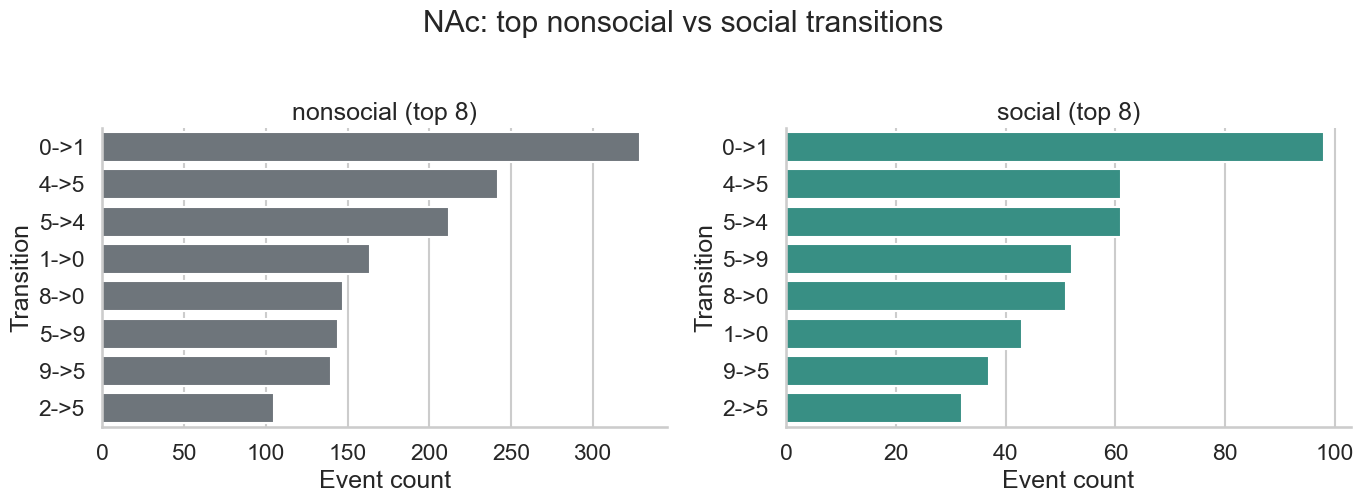

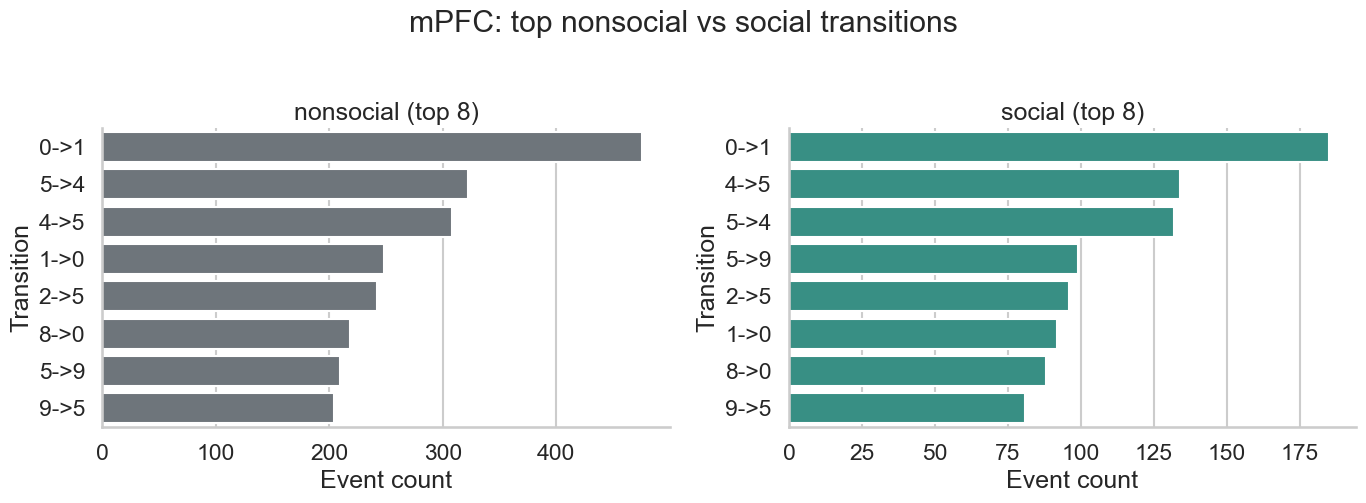

In [18]:
for region in REGION_ORDER:
    plot_top_transition_counts_by_context(
        aligned_transition_events,
        region=region,
        context_col="interaction_context",
        context_order=["nonsocial", "social"],
        top_n=TOP_N_TRANSITIONS,
        bout_phases=BOUT_PHASES,
        min_events=MIN_EVENTS_PER_TRANSITION,
        title=f"{region}: top nonsocial vs social transitions",
    )


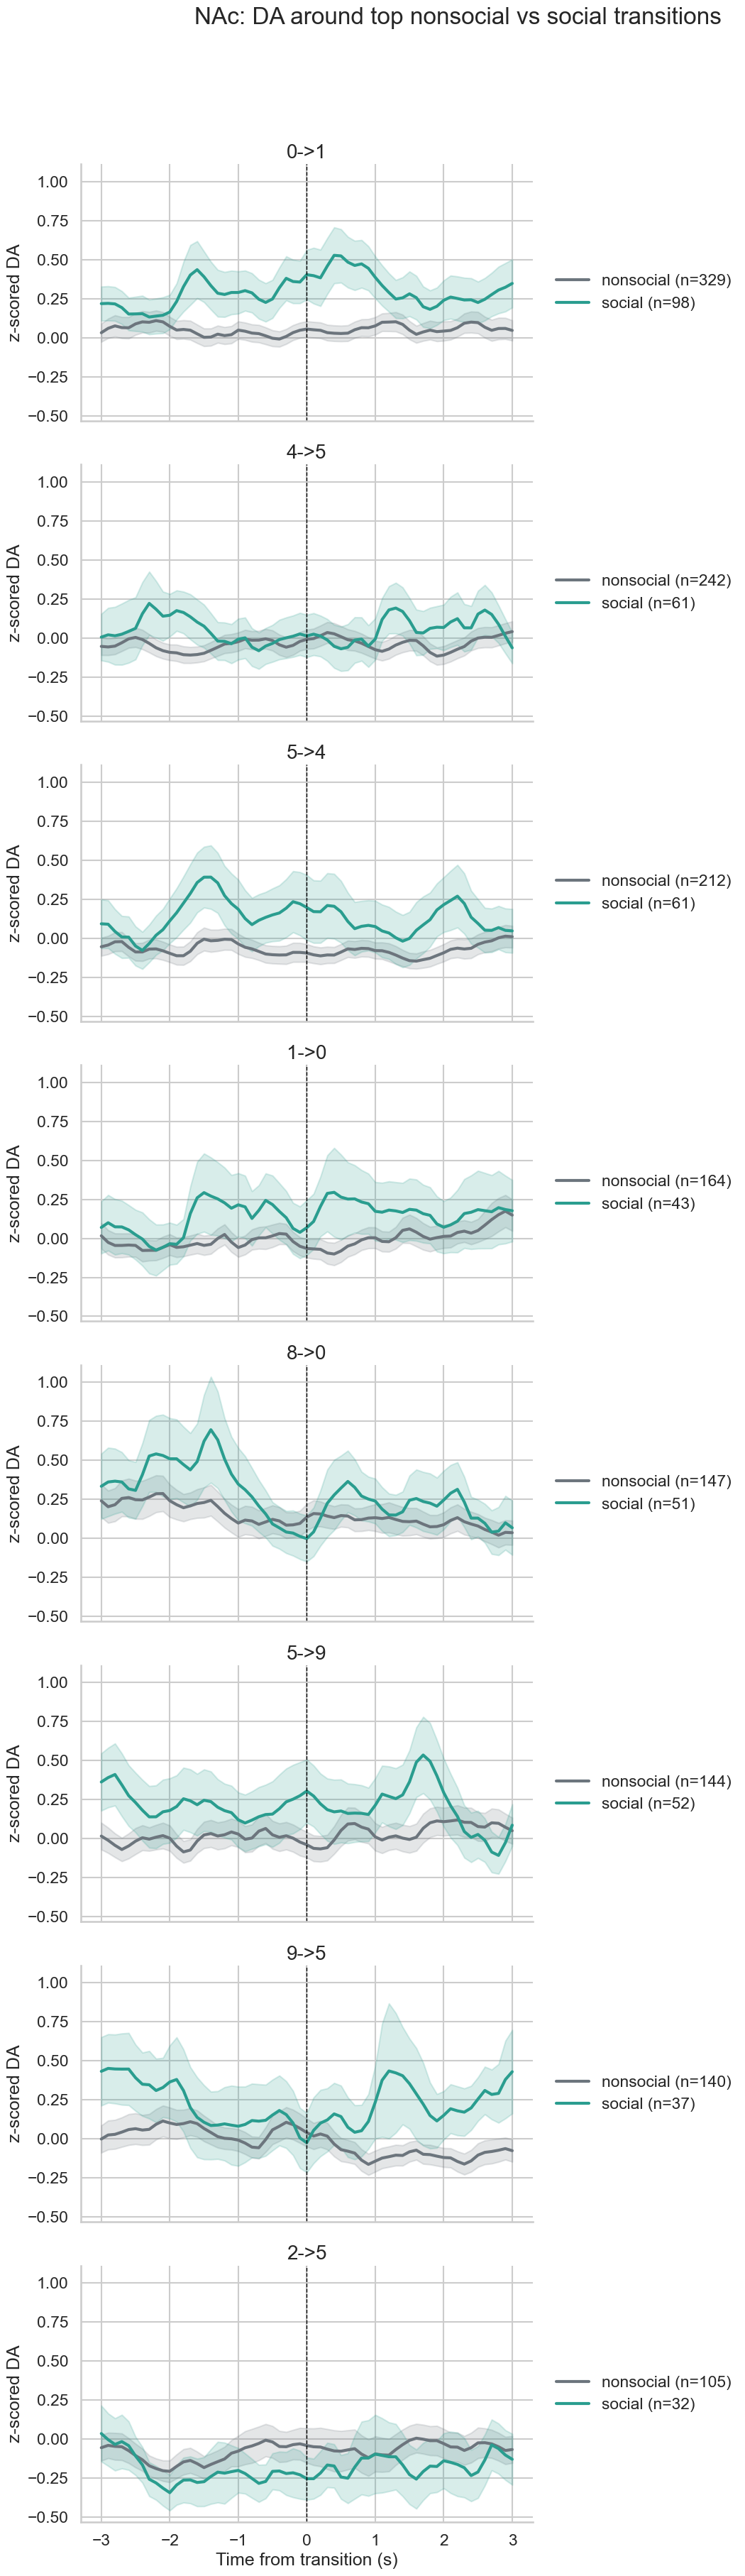

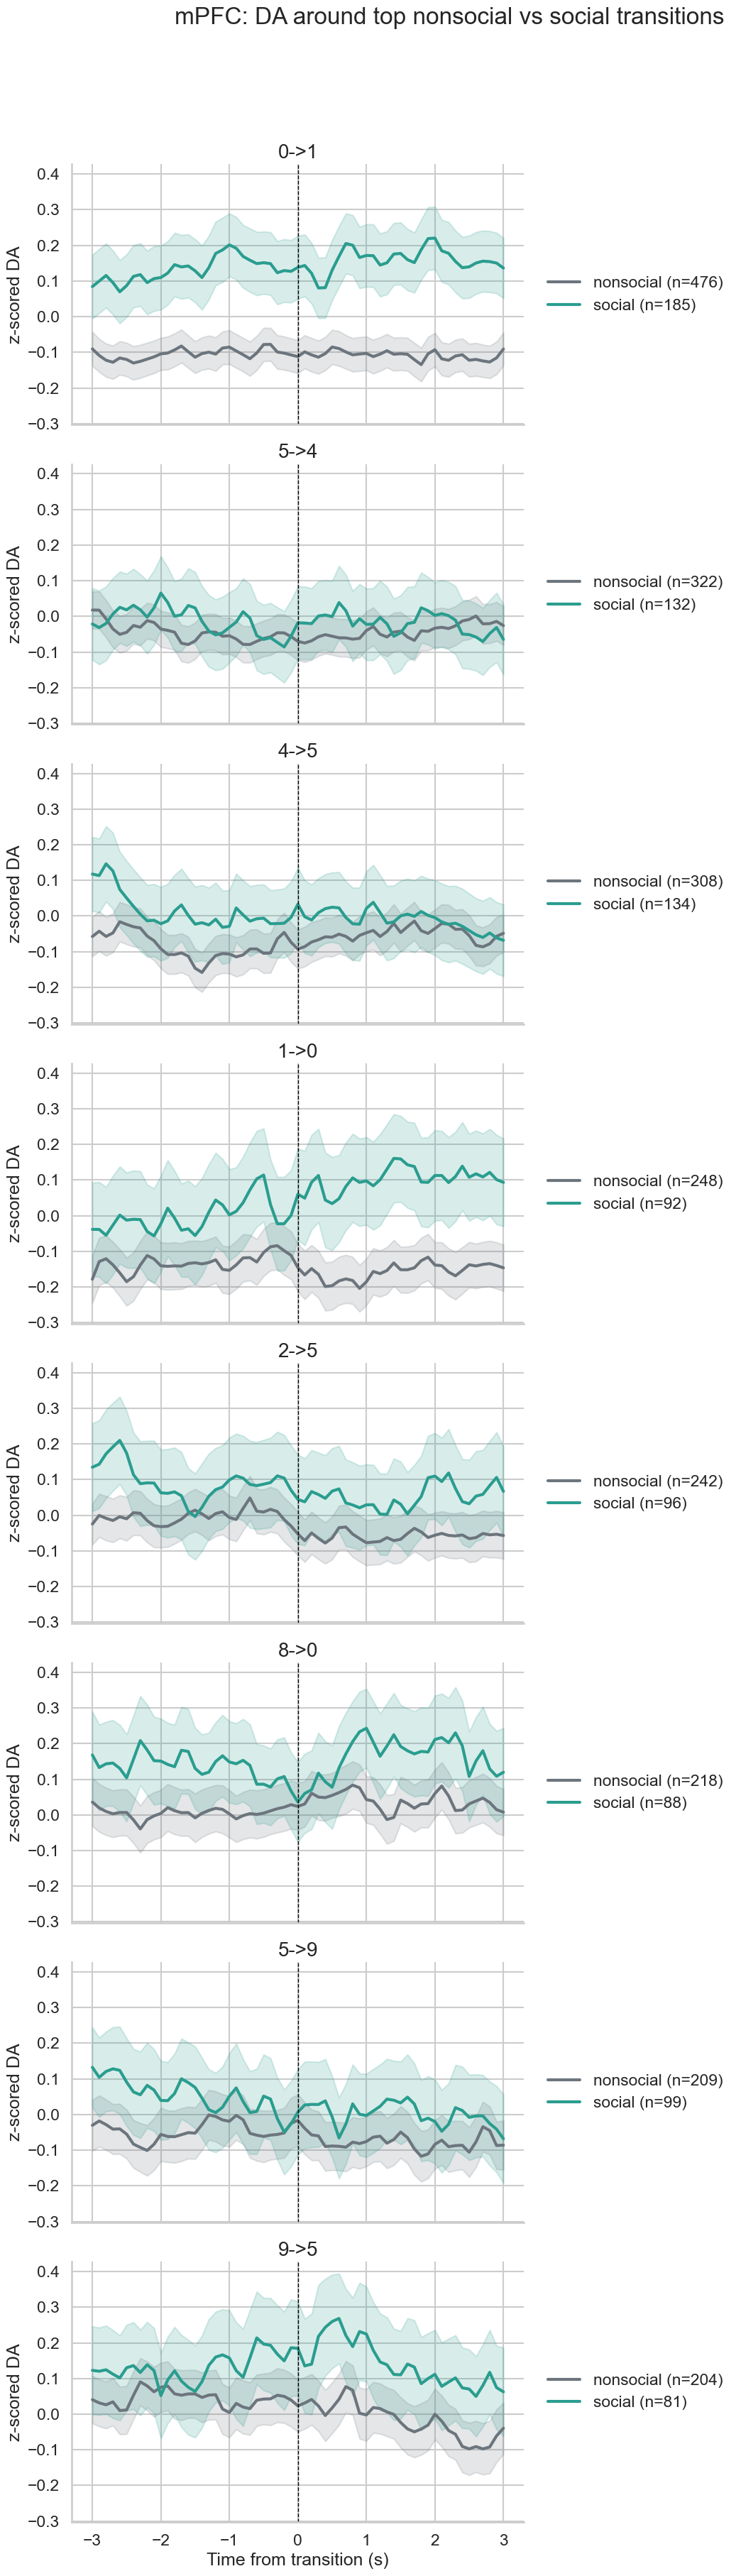

In [19]:
for region in REGION_ORDER:
    plot_transition_peth_by_context(
        aligned_transition_long,
        aligned_transition_events,
        region=region,
        context_col="interaction_context",
        context_order=["nonsocial", "social"],
        top_n=8,
        bout_phases=BOUT_PHASES,
        min_events=MIN_EVENTS_PER_TRANSITION,
        title=f"{region}: DA around top nonsocial vs social transitions",
    )


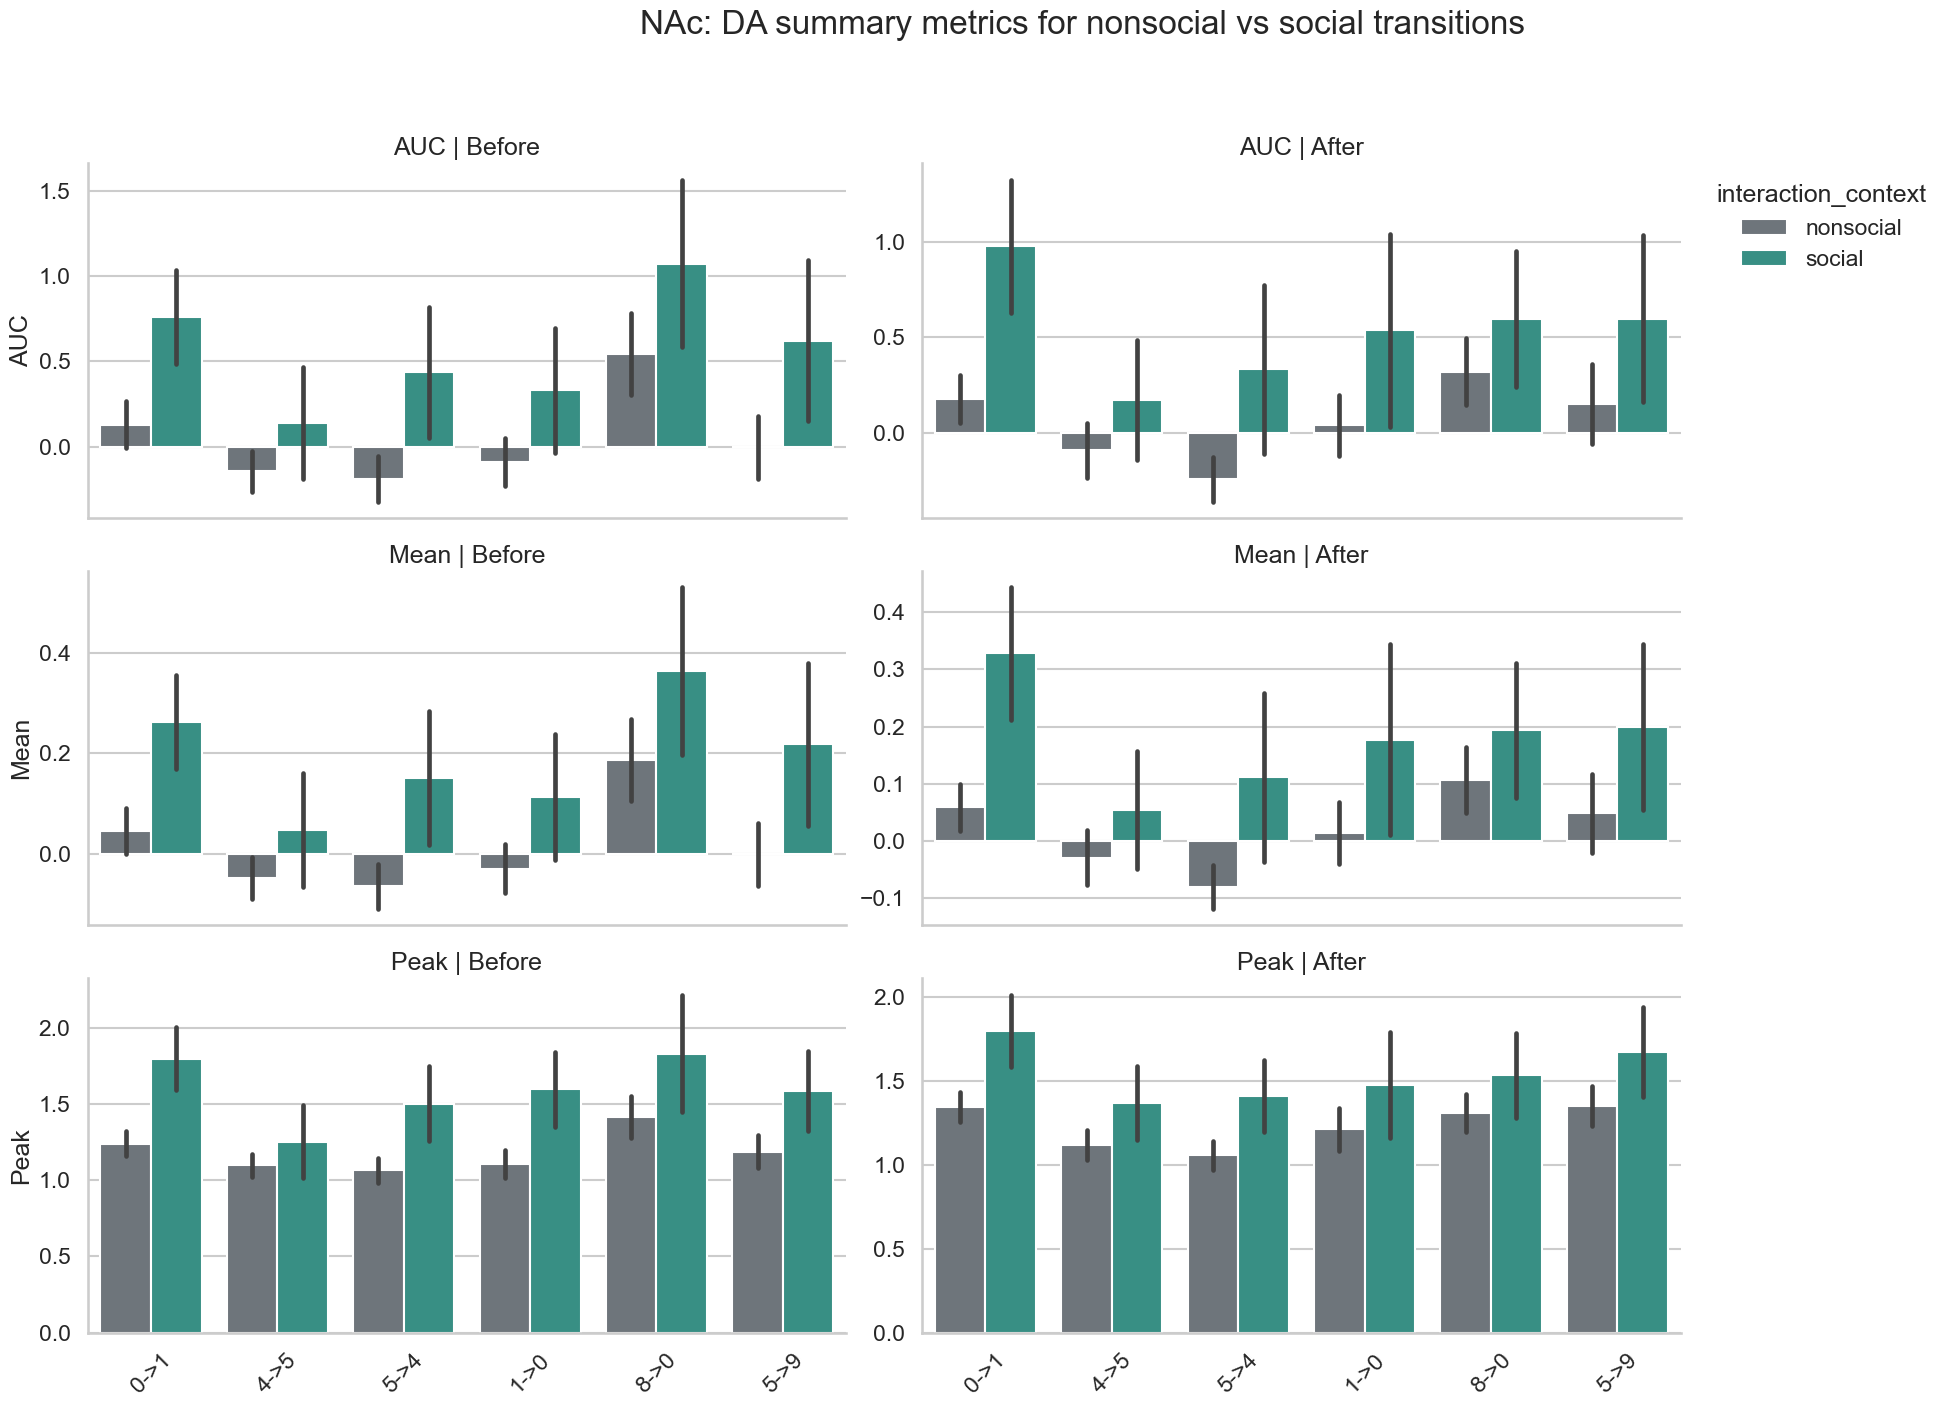

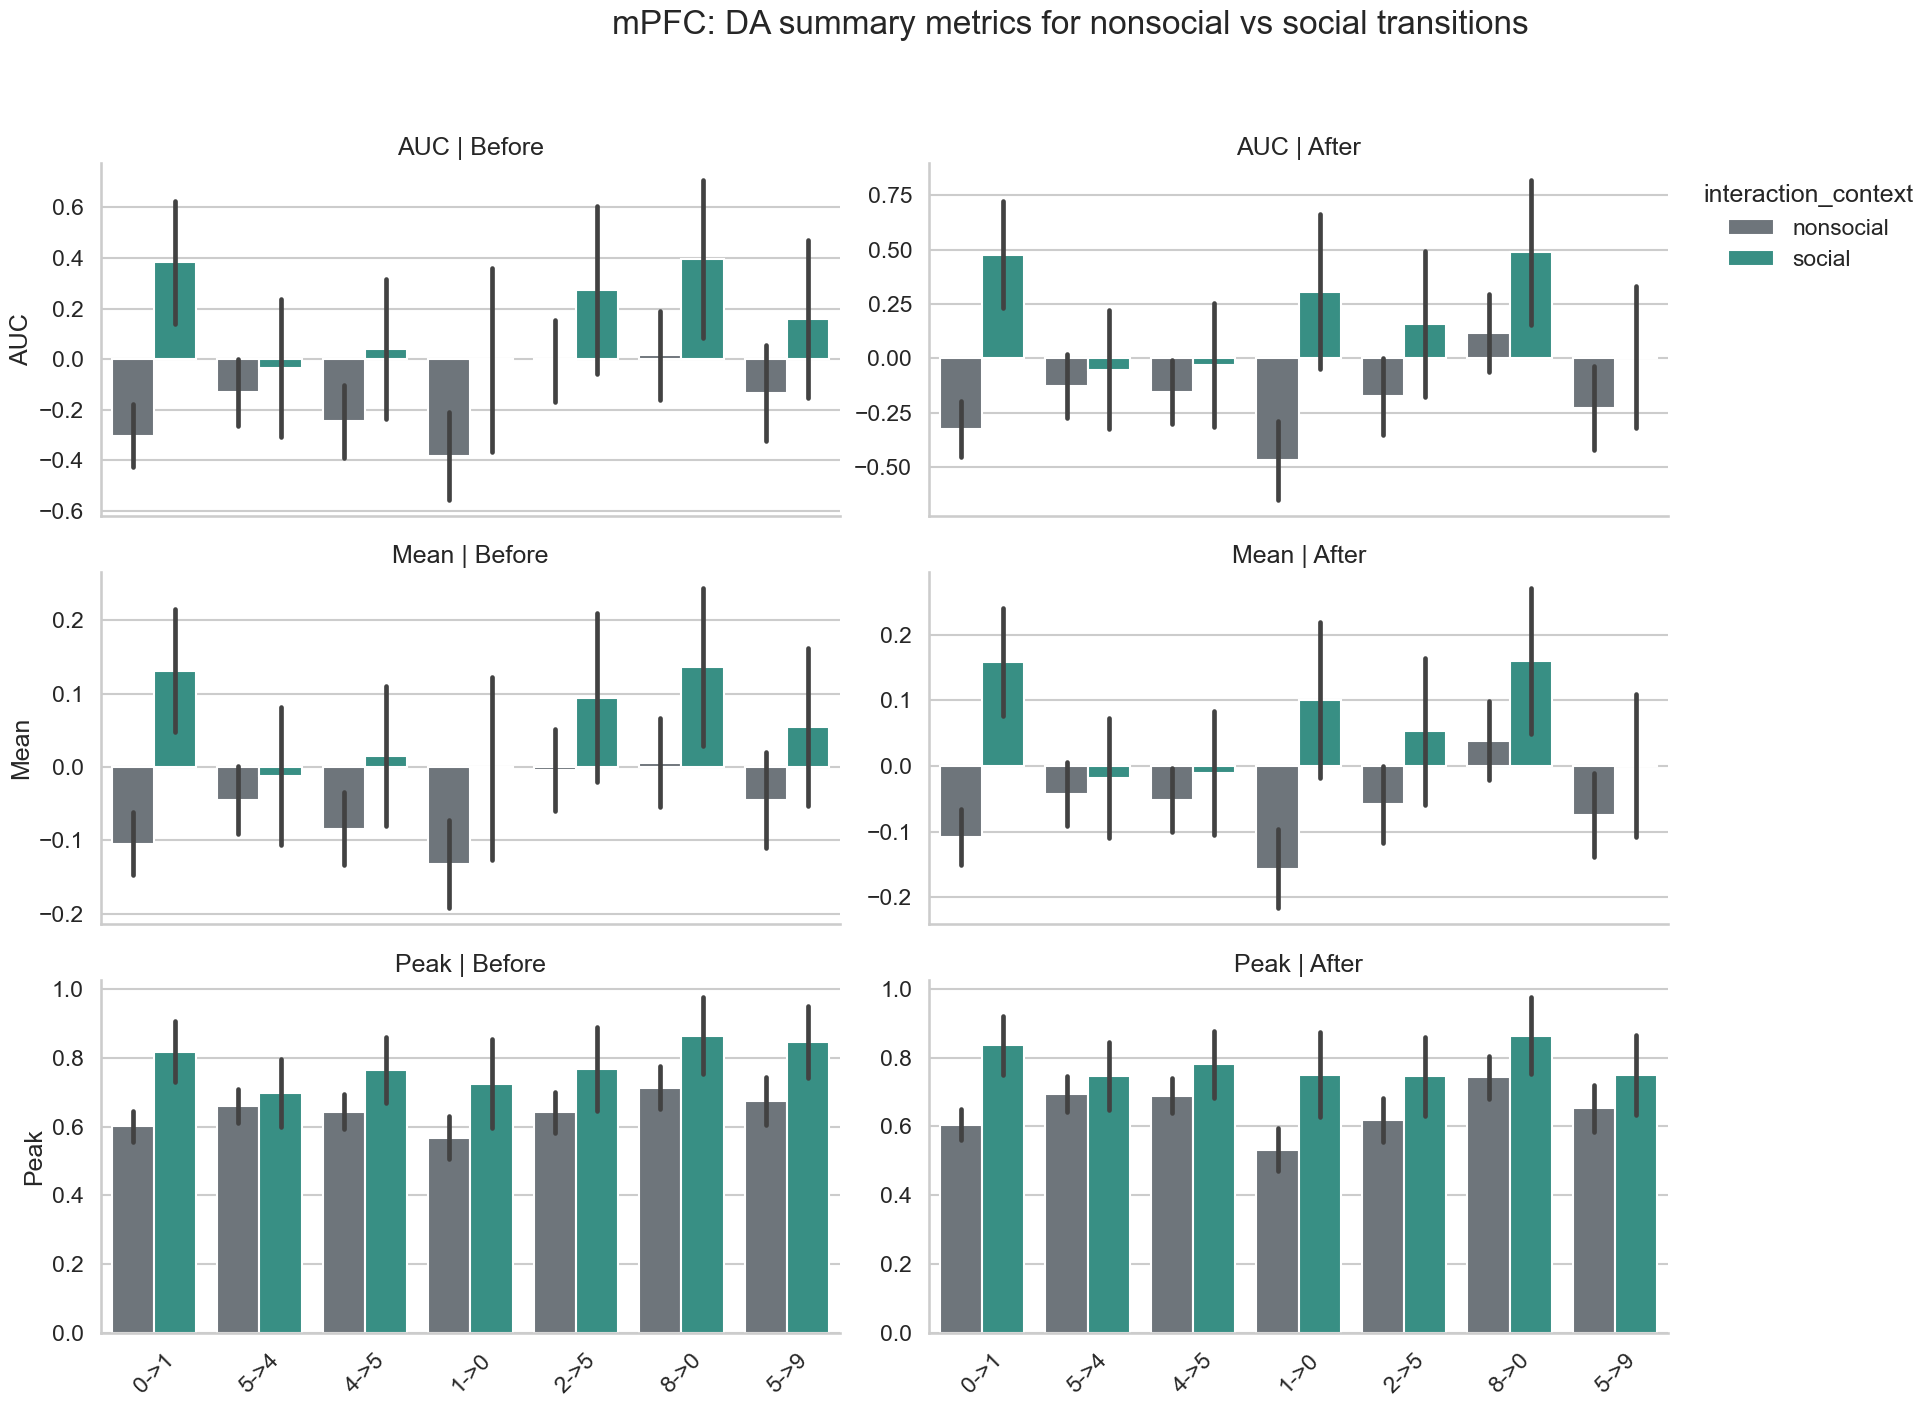

In [20]:
for region in REGION_ORDER:
    plot_transition_metrics_by_context(
        aligned_transition_events,
        region=region,
        context_col="interaction_context",
        context_order=["nonsocial", "social"],
        top_n=6,
        bout_phases=BOUT_PHASES,
        min_events=MIN_EVENTS_PER_TRANSITION,
        title=f"{region}: DA summary metrics for nonsocial vs social transitions",
    )


## Within Social Transitions: Directional Comparison

This section restricts to social transitions and compares:

- gent_in_subject
- subject_in_agent

If you also want to include frames where both are true, use the optional cell at the end.


In [21]:
aligned_transition_events["social_role_at_transition"]

0                    none
1                    none
2                    none
3                    none
4                    none
               ...       
16607                none
16608                none
16609                none
16610                none
16611    subject_in_agent
Name: social_role_at_transition, Length: 16612, dtype: object

In [22]:
aligned_transition_events

,event_id,recording_name,subject_name,brain_region,entry_time_s,entry_frame_index,from_syllable,to_syllable,bout_phase,bout_start_s,...,social_role_at_transition,mean_pre,mean_post,peak_pre,peak_post,peak_latency_s,auc_pre,auc_post,trace,rel_time_grid
0,632,n5_subject,n5,NAc,1471.1,14711,4,5,Long_Term-1,1467.9,...,none,1.877710,3.445983,5.235177,5.869750,0.2,5.403056,10.412396,"[0.260742030347053, 0.16616188235584625, 0.076...","[-3.0, -2.9, -2.8, -2.7, -2.6, -2.5, -2.4, -2...."
1,633,n5_subject,n5,NAc,1473.9,14739,5,9,Long_Term-1,1467.9,...,none,3.750707,1.243781,5.869750,2.065678,0.9,10.964926,3.789761,"[4.599815548458823, 4.340746428982587, 4.34163...","[-3.0, -2.9, -2.8, -2.7, -2.6, -2.5, -2.4, -2...."
2,634,n5_subject,n5,NAc,1474.5,14745,9,25,Long_Term-1,1467.9,...,none,2.949861,1.080196,5.828382,2.065678,0.3,8.542872,3.282916,"[5.135947686985134, 4.397328835596508, 4.31559...","[-3.0, -2.9, -2.8, -2.7, -2.6, -2.5, -2.4, -2...."
3,635,n5_subject,n5,NAc,1474.8,14748,25,20,Long_Term-1,1467.9,...,none,2.652493,0.977128,5.828382,2.065678,-0.0,7.637208,2.878503,"[4.400505279179622, 4.3317291366442525, 3.7750...","[-3.0, -2.9, -2.8, -2.7, -2.6, -2.5, -2.4, -2...."
4,636,n5_subject,n5,NAc,1475.3,14753,20,8,Long_Term-1,1467.9,...,none,2.294142,0.858497,5.828382,2.007866,0.3,6.536808,2.526872,"[5.317258891056424, 5.8283821738365225, 5.5678...","[-3.0, -2.9, -2.8, -2.7, -2.6, -2.5, -2.4, -2...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16607,16523,pp8_subject,pp8,mPFC,482.7,4827,3,2,Short_Term-1,185.2,...,none,-0.095577,0.127006,0.622470,0.832115,1.0,-0.273692,0.382139,"[-0.8420898842859695, -0.9229765949891017, -0....","[-3.0, -2.9, -2.8, -2.7, -2.6, -2.5, -2.4, -2...."
16608,16524,pp8_subject,pp8,mPFC,483.8,4838,2,5,Short_Term-1,185.2,...,none,0.154605,-0.058856,0.832115,0.560286,1.3,0.431765,-0.215083,"[-0.1911060944414401, 0.043833695942898696, -0...","[-3.0, -2.9, -2.8, -2.7, -2.6, -2.5, -2.4, -2...."
16609,16525,pp8_subject,pp8,mPFC,483.9,4839,5,9,Short_Term-1,185.2,...,none,0.179303,-0.070366,0.832115,0.560286,1.2,0.508226,-0.244642,"[0.0438336959429261, -0.03630051124442466, 0.0...","[-3.0, -2.9, -2.8, -2.7, -2.6, -2.5, -2.4, -2...."
16610,16526,pp8_subject,pp8,mPFC,484.5,4845,9,13,Short_Term-1,185.2,...,none,0.204824,-0.120605,0.832115,0.560286,0.6,0.602828,-0.359336,"[0.1267645240414757, 0.32912346951680604, 0.43...","[-3.0, -2.9, -2.8, -2.7, -2.6, -2.5, -2.4, -2...."


In [23]:
social_direction_events = aligned_transition_events[
    aligned_transition_events["social_role_at_transition"].isin(["agent_in_subject", "subject_in_agent"])
].copy()
social_direction_long = aligned_transition_long[
    aligned_transition_long["event_id"].isin(social_direction_events["event_id"])
].copy()

print(f"Directional social events: {len(social_direction_events):,}")
display(
    summarize_transition_counts(
        social_direction_events,
        context_col="social_role_at_transition",
        context_order=["agent_in_subject", "subject_in_agent"],
        min_events=MIN_EVENTS_PER_TRANSITION,
    ).head(20)
)


Directional social events: 2,498


,social_role_at_transition,transition_label,n_events,n_subjects
0,agent_in_subject,0->1,77,22
1,agent_in_subject,5->4,62,21
2,agent_in_subject,4->5,58,21
3,agent_in_subject,5->9,39,17
4,agent_in_subject,8->0,35,15
5,agent_in_subject,9->5,32,16
6,agent_in_subject,2->5,31,12
7,agent_in_subject,1->0,27,16
8,agent_in_subject,5->3,26,15
9,agent_in_subject,3->2,24,11


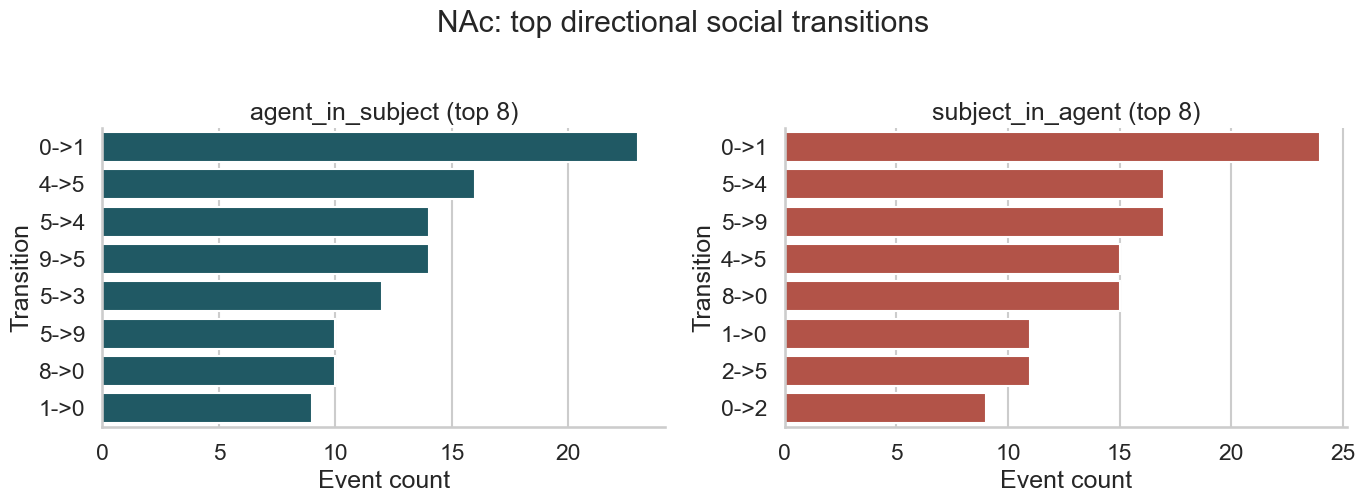

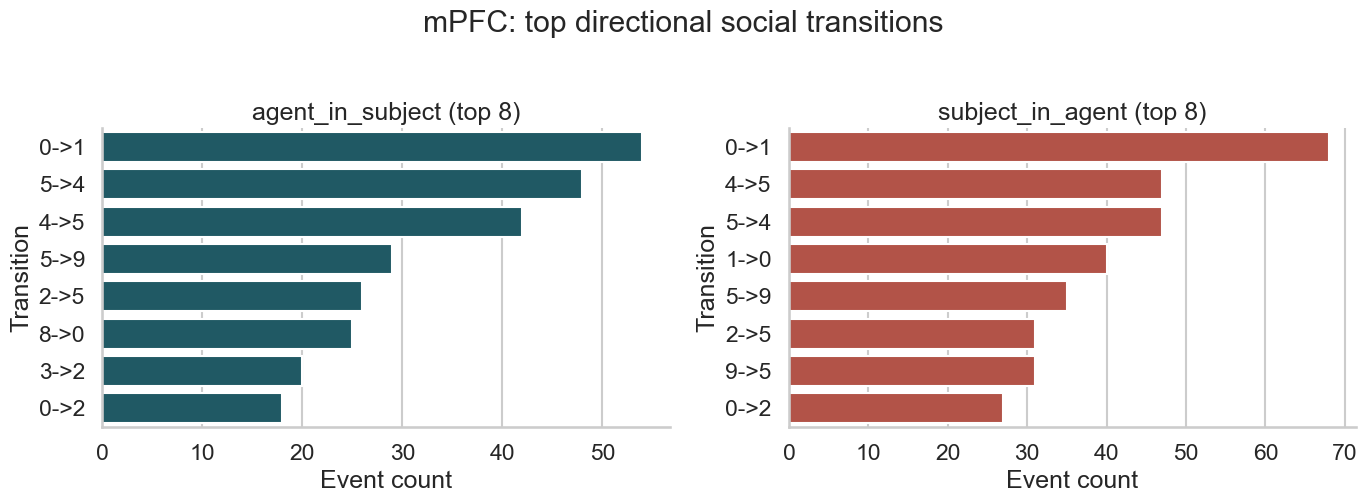

In [24]:
for region in REGION_ORDER:
    plot_top_transition_counts_by_context(
        social_direction_events,
        region=region,
        context_col="social_role_at_transition",
        context_order=["agent_in_subject", "subject_in_agent"],
        top_n=TOP_N_TRANSITIONS,
        bout_phases=BOUT_PHASES,
        min_events=MIN_EVENTS_PER_TRANSITION,
        title=f"{region}: top directional social transitions",
    )


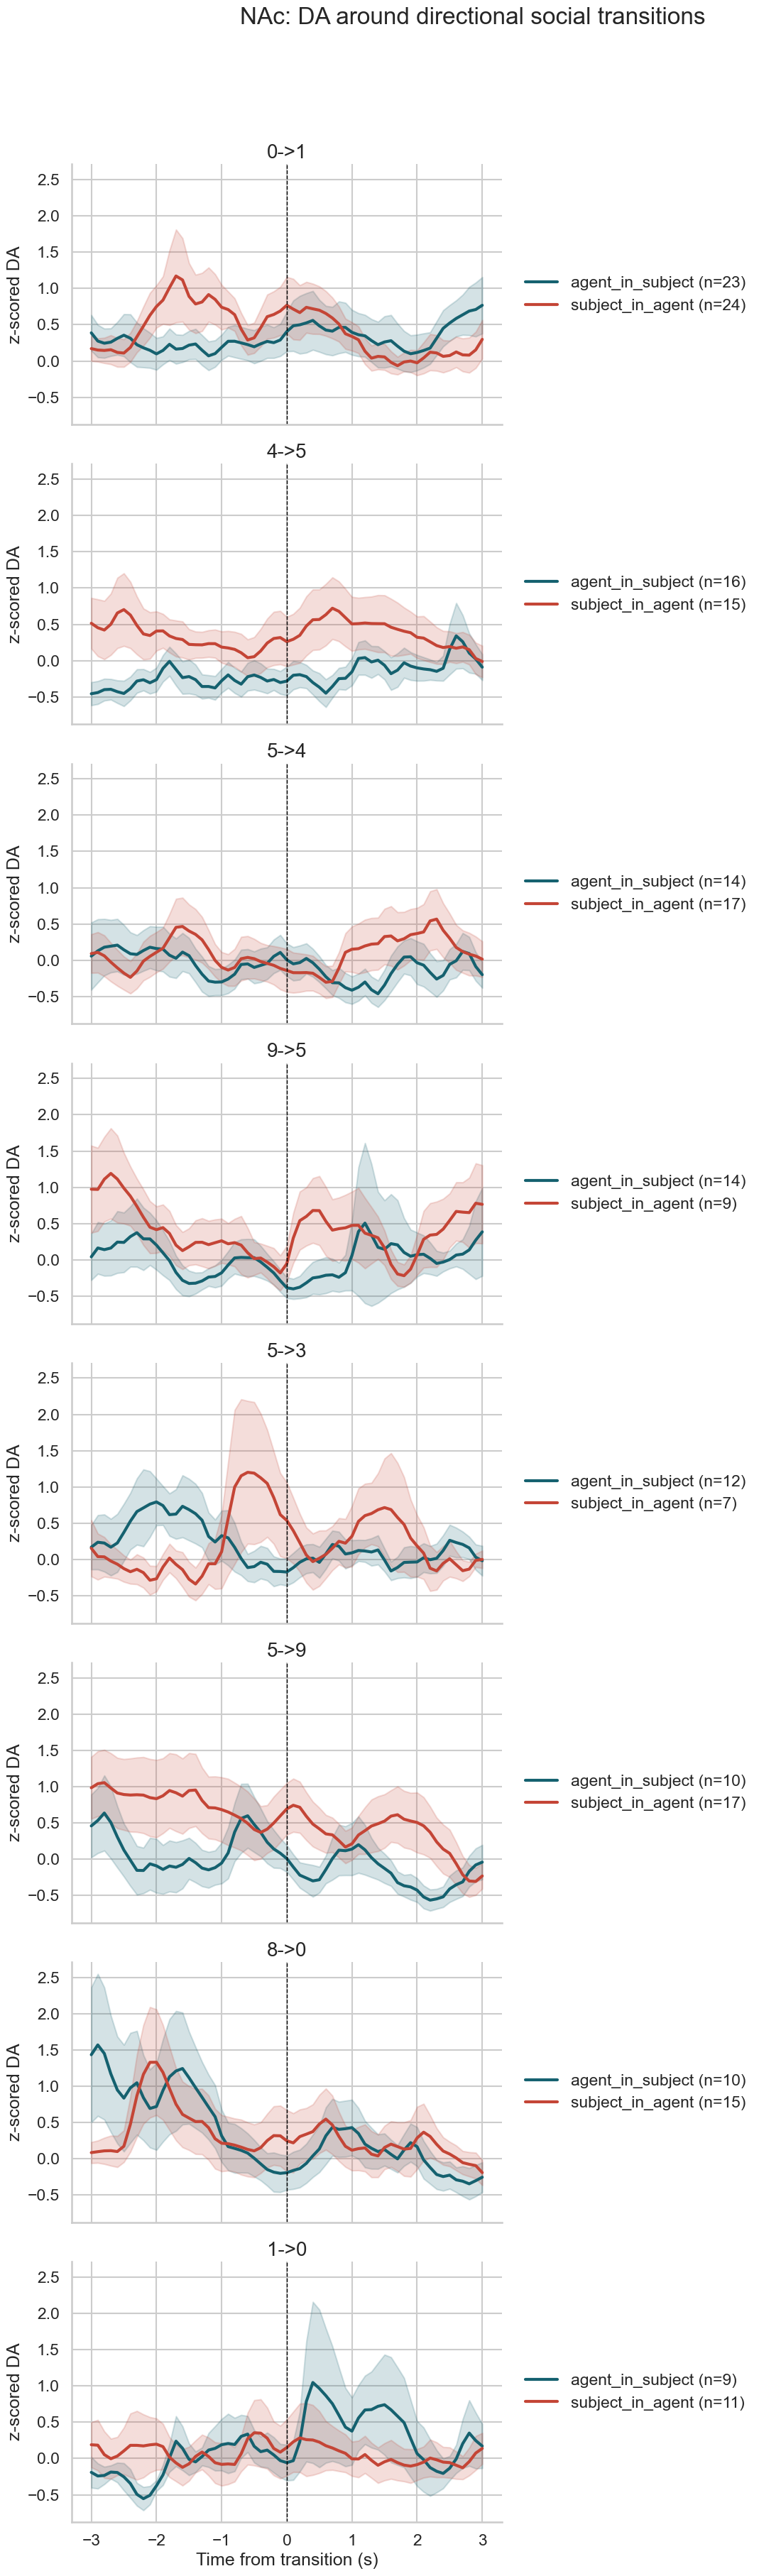

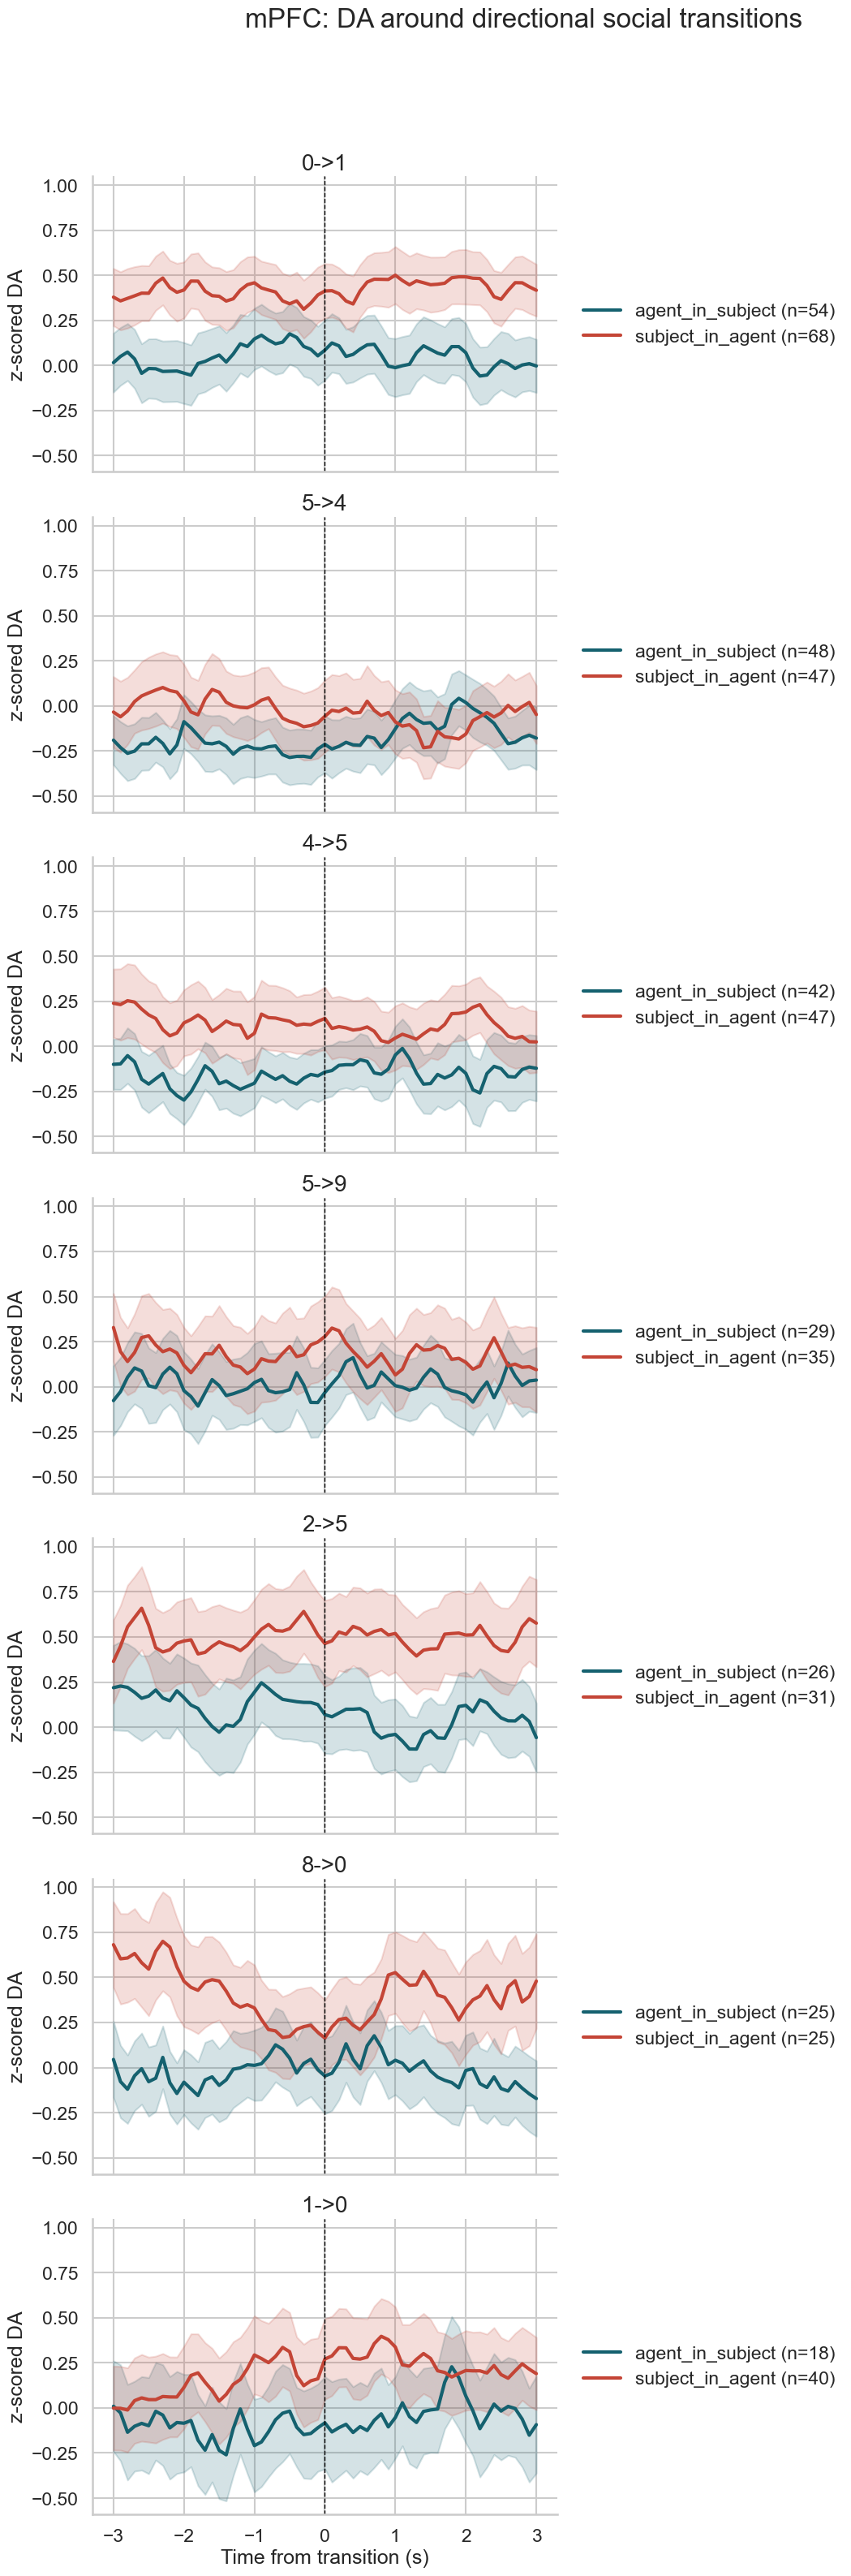

In [25]:
for region in REGION_ORDER:
    plot_transition_peth_by_context(
        social_direction_long,
        social_direction_events,
        region=region,
        context_col="social_role_at_transition",
        context_order=["agent_in_subject", "subject_in_agent"],
        top_n=6,
        bout_phases=BOUT_PHASES,
        min_events=MIN_EVENTS_PER_TRANSITION,
        title=f"{region}: DA around directional social transitions",
    )


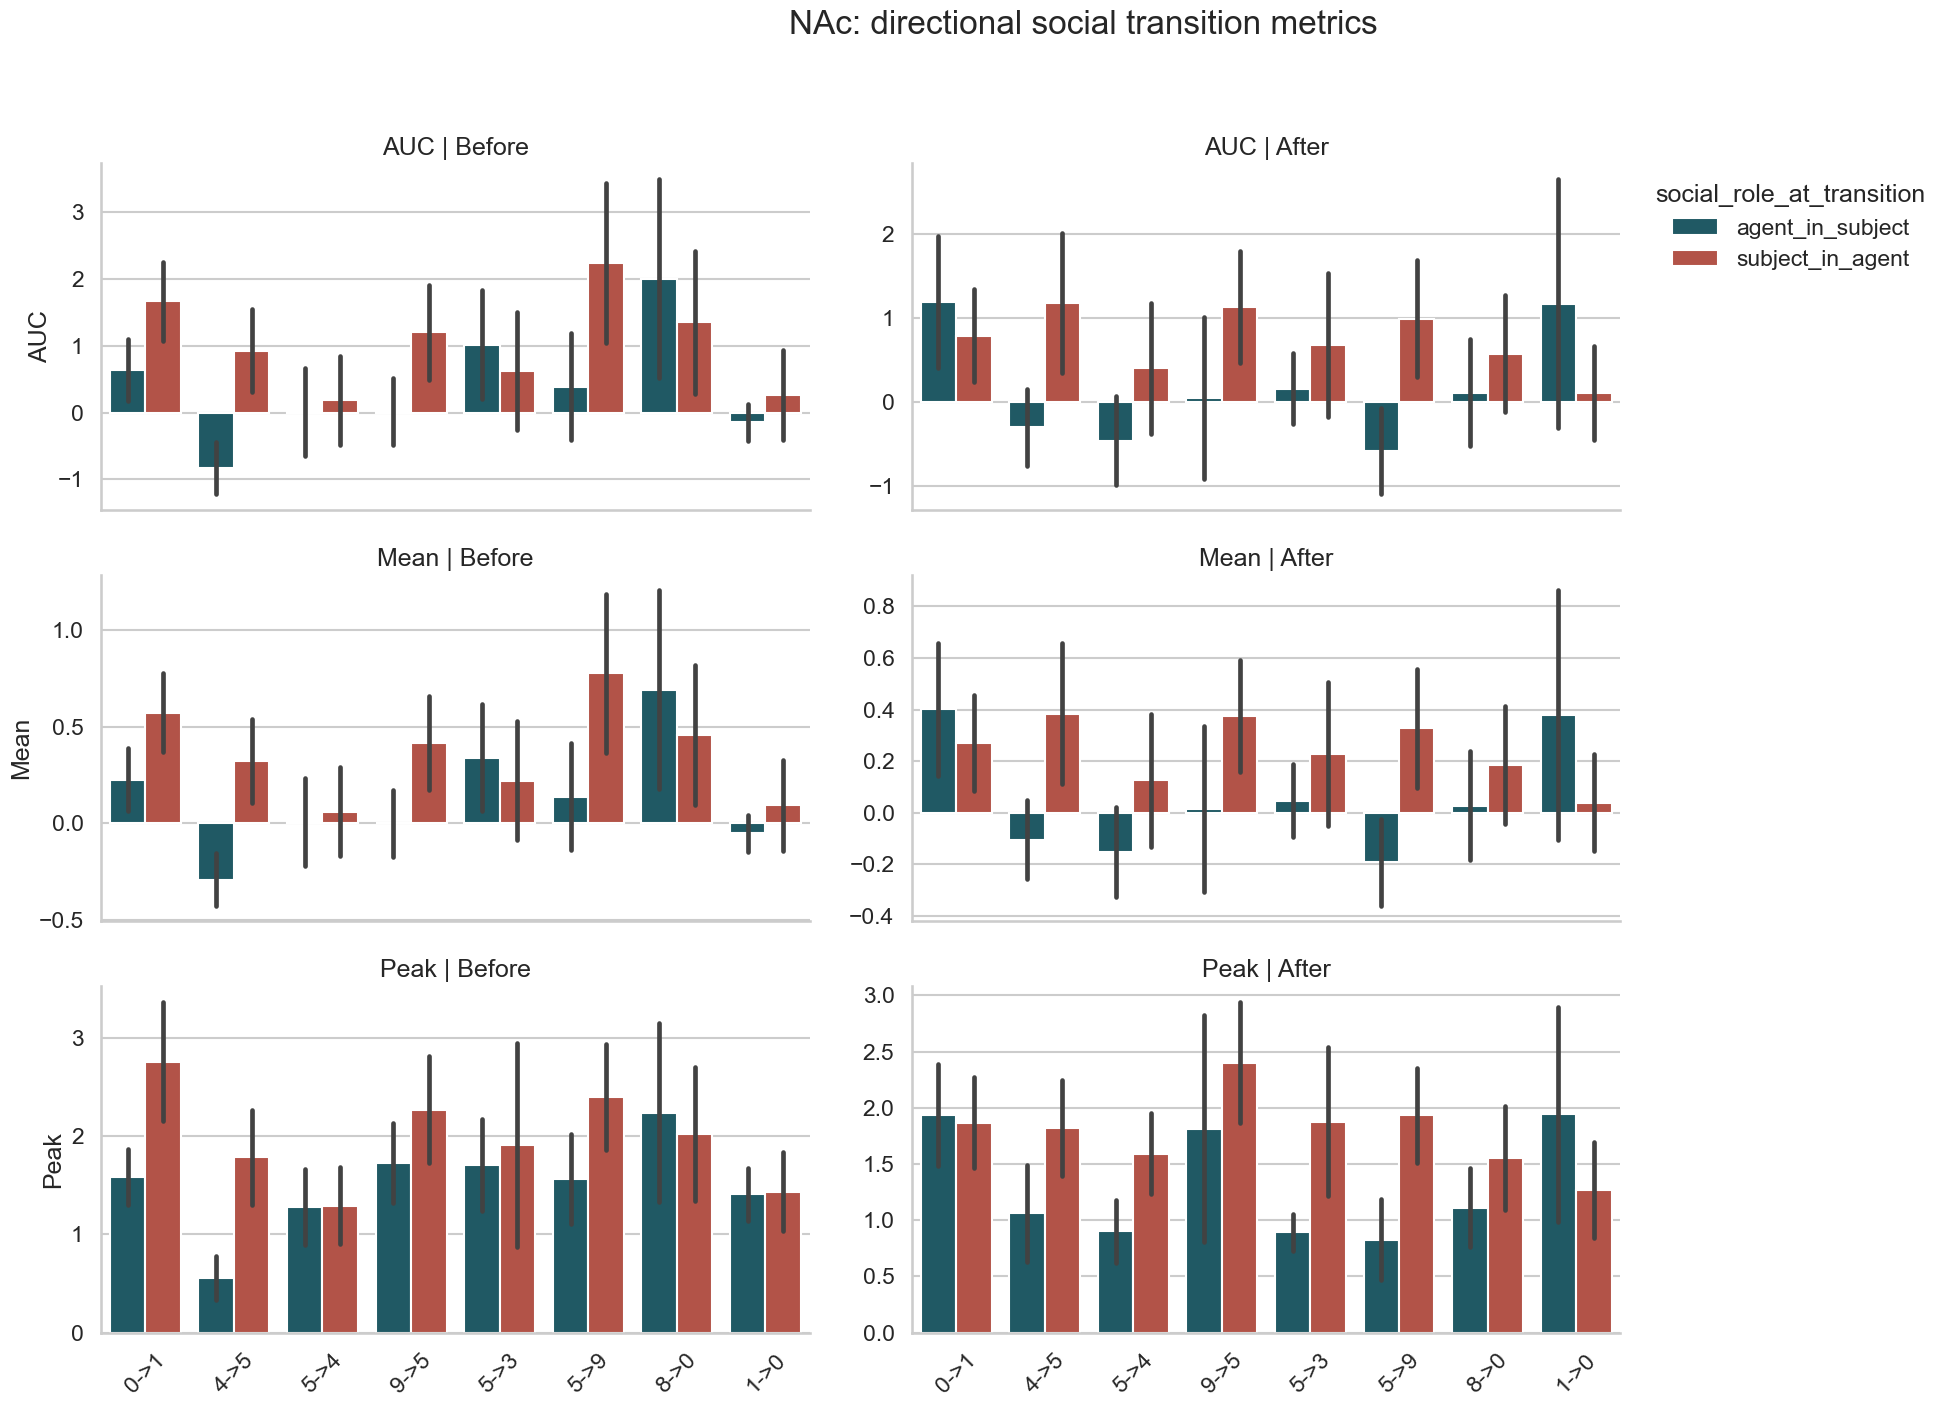

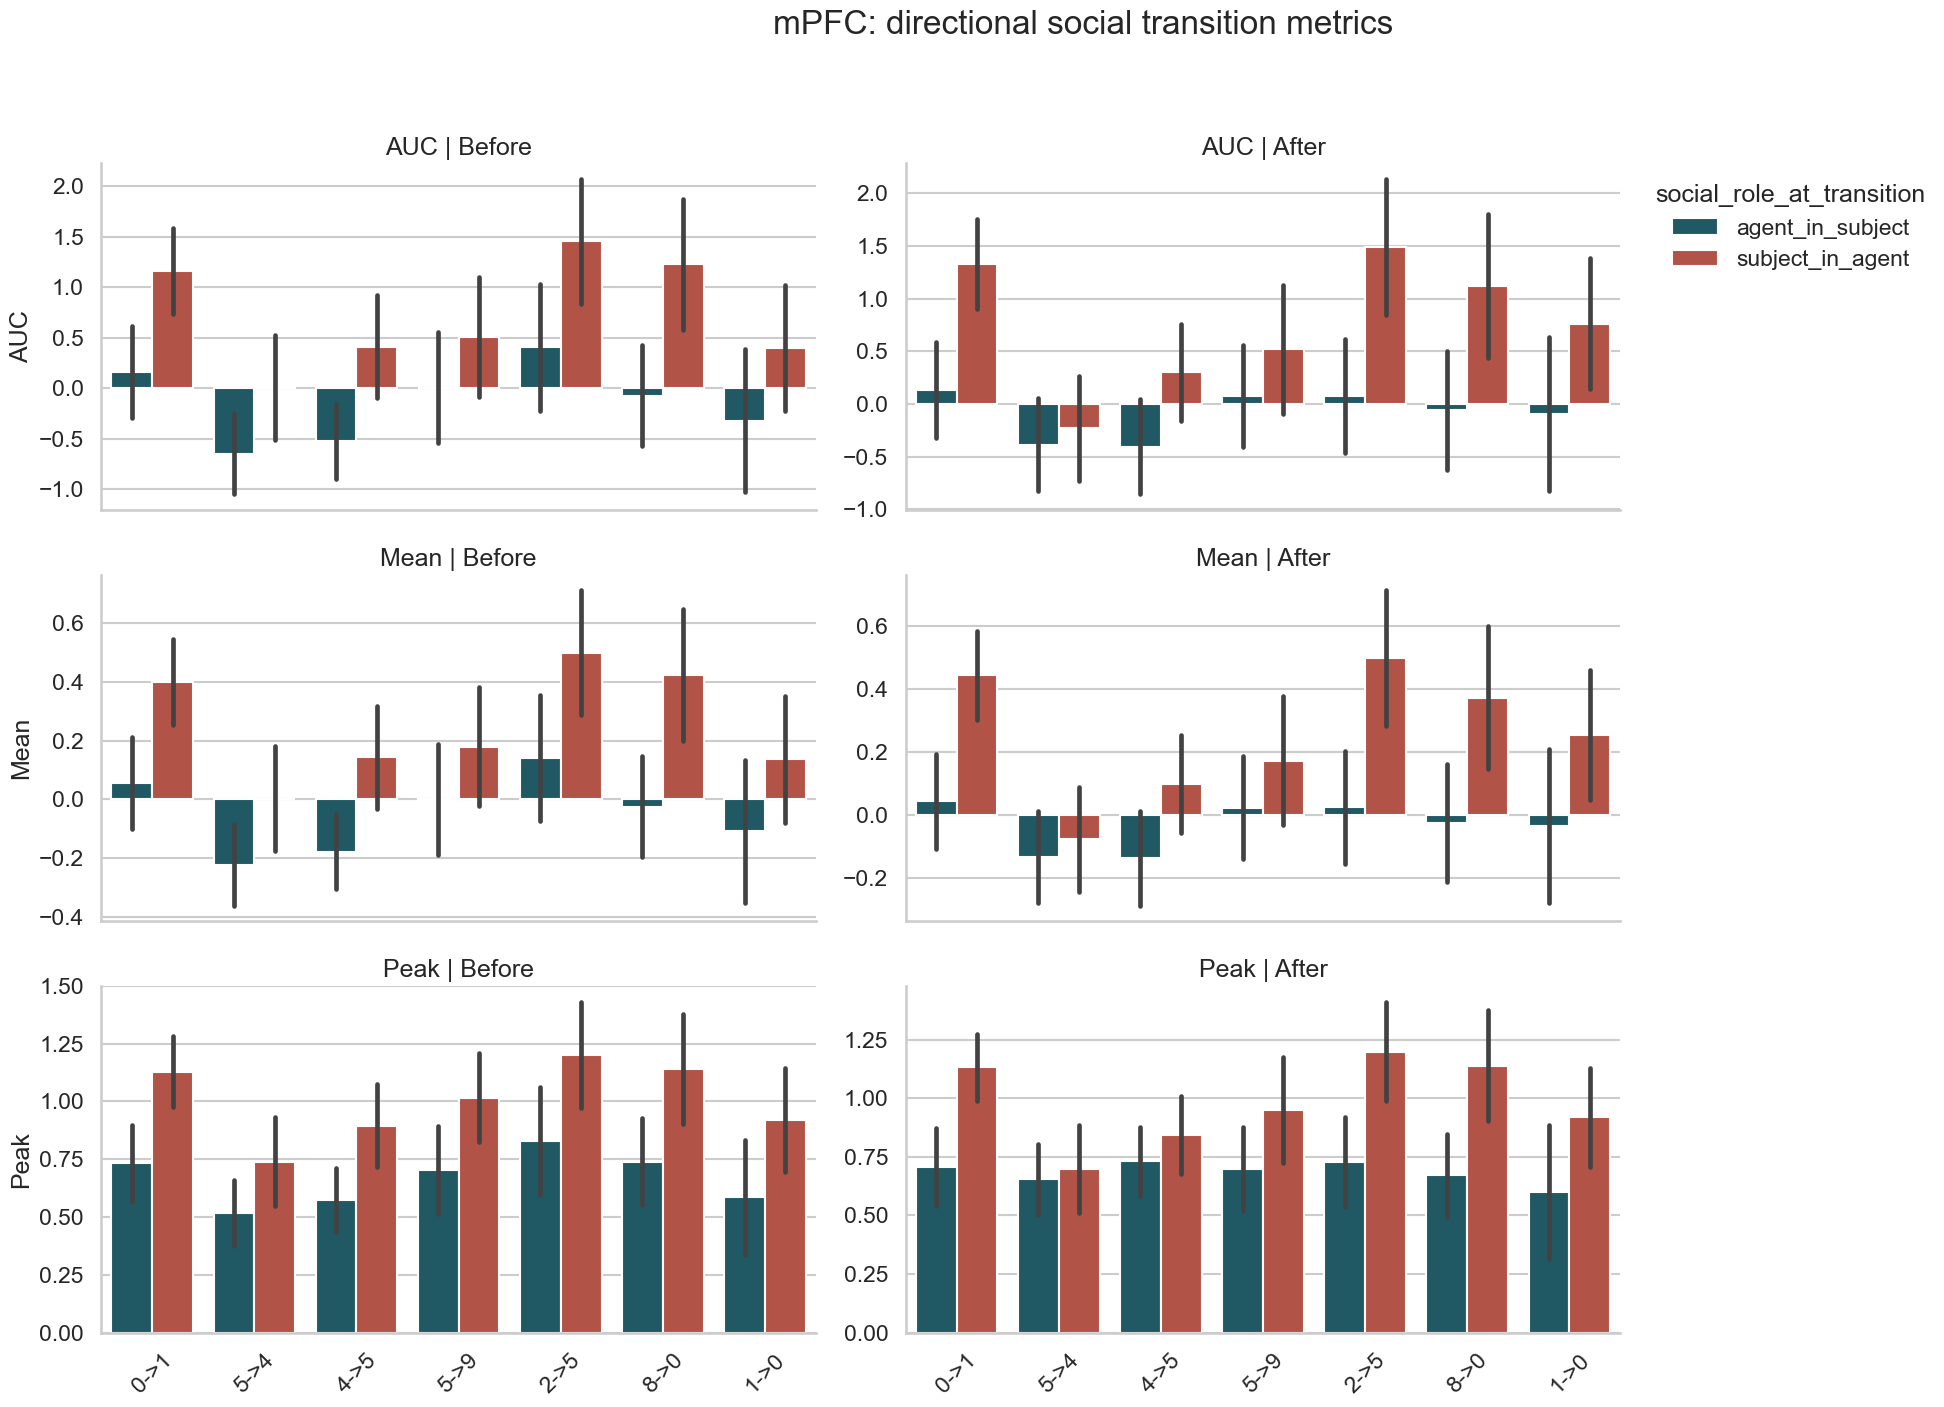

In [26]:
for region in REGION_ORDER:
    plot_transition_metrics_by_context(
        social_direction_events,
        region=region,
        context_col="social_role_at_transition",
        context_order=["agent_in_subject", "subject_in_agent"],
        top_n=6,
        bout_phases=BOUT_PHASES,
        min_events=MIN_EVENTS_PER_TRANSITION,
        title=f"{region}: directional social transition metrics",
    )


## Optional: Include oth

If you want to keep the mixed-contact frames instead of excluding them from the
directional comparison, use this optional view.


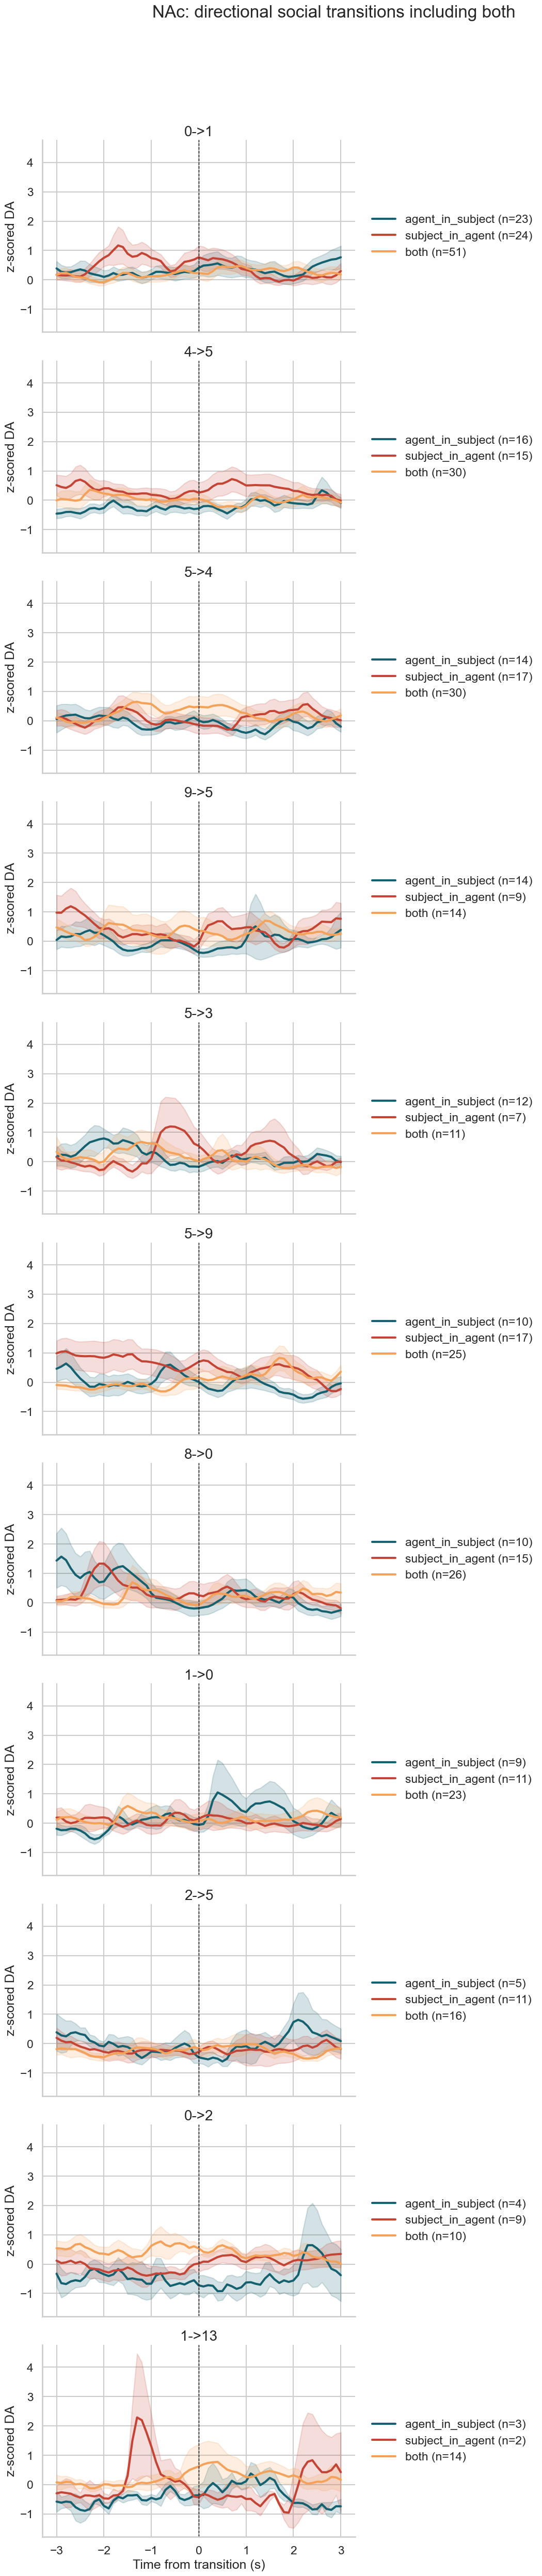

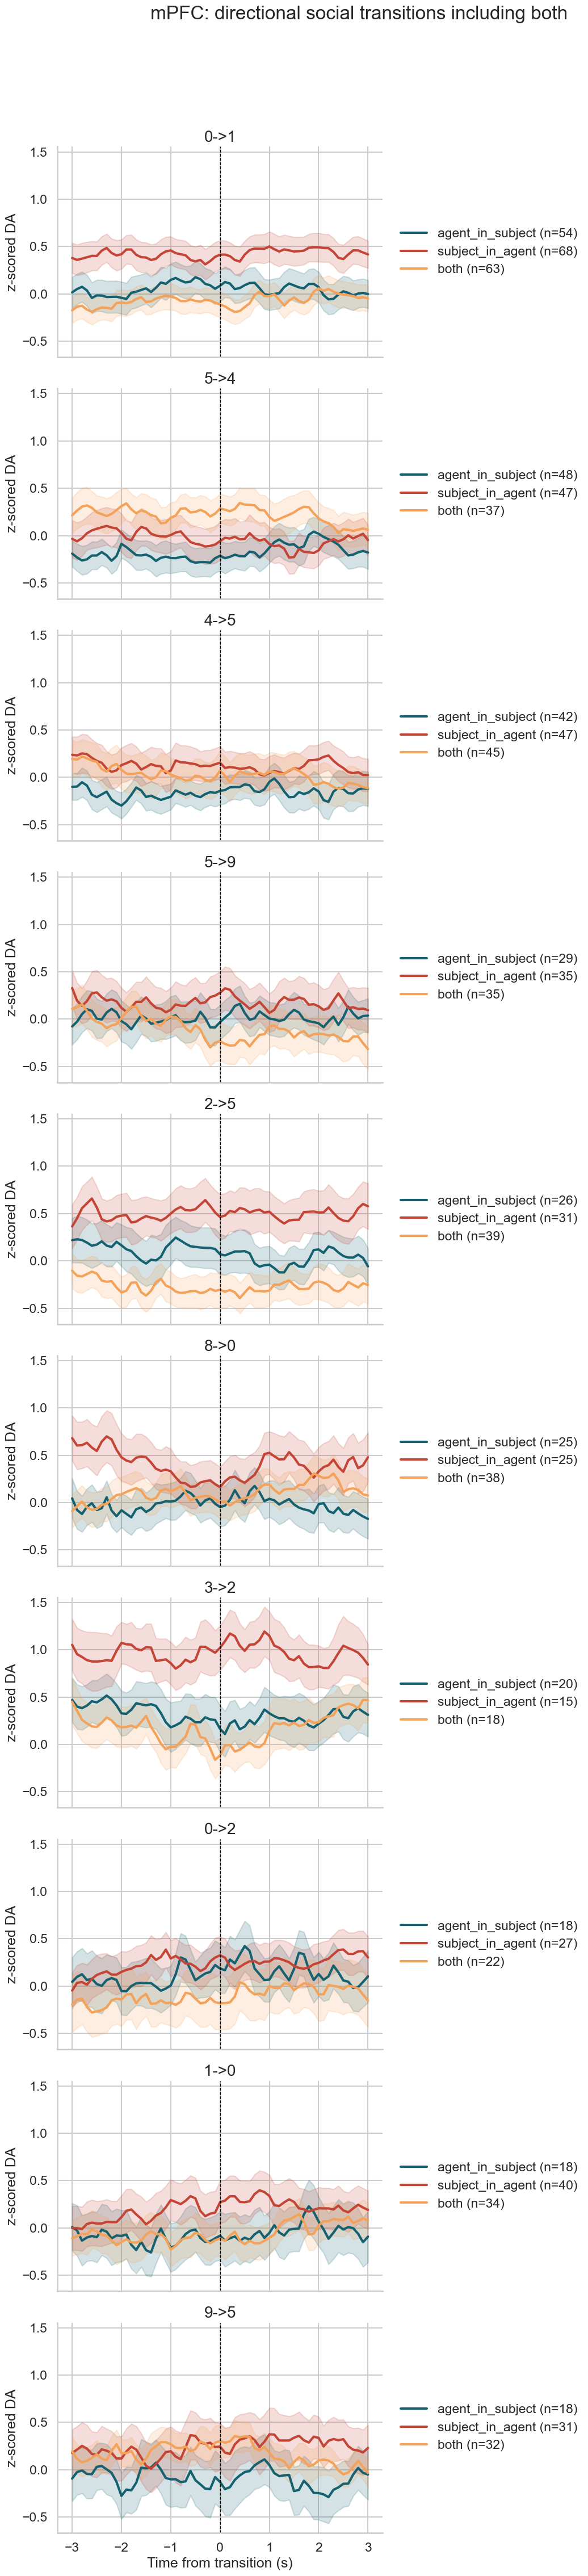

In [27]:
social_with_both_events = aligned_transition_events[
    aligned_transition_events["social_role_at_transition"].isin(
        ["agent_in_subject", "subject_in_agent", "both"]
    )
].copy()
social_with_both_long = aligned_transition_long[
    aligned_transition_long["event_id"].isin(social_with_both_events["event_id"])
].copy()

for region in REGION_ORDER:
    plot_transition_peth_by_context(
        social_with_both_long,
        social_with_both_events,
        region=region,
        context_col="social_role_at_transition",
        context_order=["agent_in_subject", "subject_in_agent", "both"],
        top_n=8,
        bout_phases=BOUT_PHASES,
        min_events=MIN_EVENTS_PER_TRANSITION,
        title=f"{region}: directional social transitions including both",
    )
